# <span style="color:#006400">🧩 STORYTELLING COM DADOS</span>  

#EXPLORANDO A BASE DE DADOS DE UM E-COMMERCE

#Neste notebook vamos explorar a base de dados de um E-Commerce a partir de uma perspectiva analítica e narrativa que permita entender a "dor de negócio" descrita no contexto a seguir:

Esse E-Commerce teve crescimento nos últimos anos que trouxe ganhos importantes de escala,  mas também revelou desafios relevantes na experiência do cliente, especialmente  refletidos na alta variabilidade do Net Promoter Score (NPS) entre diferentes perfis de  consumidores.    

A área de Experiência do Cliente percebeu que, mesmo com  indicadores operacionais aparentemente semelhantes, alguns clientes se tornam  promotores da marca, enquanto outros se tornam detratores.    

Essa diferença levanta uma questão central para o negócio: quais fatores  operacionais realmente influenciam a satisfação do cliente e como a empresa  pode agir de forma proativa para melhorar a experiência antes mesmo da  aplicação da pesquisa de NPS?    

##Contextualização importante:

Pontuação NPS na escala (0 a 10)  

Detrator (0–6)  
Neutro (7–8)  
Promotor (9–10)

#**1**.Importação de bibliotecas e configurações iniciais

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

#libs gráficas
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

#Avisos
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [ ]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)

#**2**.Contexto e carregamento dos dados  

📌Antes de analisar a dor de negócio e suas causas, precisamos entender com que dados estamos trabalhando. Nesta etapa, vamos carregar a base de dados do E-Commerce, observar suas principais colunas, conferir tamanho da base, descrições, tipos e conteúdos dos dados, identificar possiveis dados nulos, dados duplicados, outliers, eventuais implicações de contéudos zerados ou conteúdos com strings vazias

In [ ]:
df_desafio_nps_fase_1_original = pd.read_csv('/content/drive/MyDrive/FIAP - POS TECH - AI SCIENTIST /Fase 1 - Business understanding and data analysis/TechChallenge_1/desafio_nps_fase_1.csv')


#**2.1** Tamanho da Base de Dados

In [ ]:
df_desafio_nps_fase_1_original.shape

(2500, 19)

## 🔍A base de dados original tem 2500 linhas e 19 colunas

#**2.2** Colunas da Base de Dados

In [ ]:
df_desafio_nps_fase_1_original.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


## 🔍Todas as colunas estão com termos em inglês.  

##Para efeitos de facilitação de entendimento procederemos com a alteração do nome das colunas considerando o documento, reproduzido a seguir, fornecido pela área de negócios, que descreve as colunas da seguinte forma:

customer_id: Identificador único do cliente.  
order_id: Identificador único do pedido.  
customer_age: Idade do cliente.  
customer_region: Região geográfica do cliente.  
customer_tenure_months: Tempo de relacionamento do cliente com a empresa (em meses).  
order_value: Valor total do pedido.  
items_quantity: Quantidade de itens no pedido.  
discount_value: Valor de desconto aplicado ao pedido.  
payment_installments: Número de parcelas do pagamento.  
delivery_time_days: Tempo total de entrega (em dias).  
delivery_delay_days: Quantidade de dias de atraso na entrega.  
freight_value: Valor do frete.  
delivery_attempts: Número de tentativas de entrega.  
customer_service_contacts: Número de contatos do cliente com o atendimento.  
resolution_time_days: Tempo para resolução de problemas (em dias).  
complaints_count: Número de reclamações registradas pelo cliente.  
repeat_purchase_30d: Indica se houve recompra em até 30 dias após o pedido (0 = não, 1 = sim).  
csat_internal_score: Score interno de satisfação do cliente.  
nps_score: Nota de satisfação do cliente (NPS), variando de 0 a 10, coletada após a experiência de compra.  

In [ ]:
df_desafio_nps_fase_1 = df_desafio_nps_fase_1_original.rename(columns={
     "customer_id": "id_cliente",
    "order_id": "id_pedido",
    "customer_age": "idade_cliente",
    "customer_region": "regiao_cliente",
    "customer_tenure_months": "tempo_relacionamento_cliente_meses",
    "order_value": "valor_pedido",
    "items_quantity": "quantidade_itens",
    "discount_value": "valor_desconto",
    "payment_installments": "numero_parcelas_pagamento",
    "delivery_time_days": "tempo_entrega_dias",
    "delivery_delay_days": "atraso_entrega_dias",
    "freight_value": "valor_frete",
    "delivery_attempts": "tentativas_entrega",
    "customer_service_contacts": "contatos_atendimento_cliente",
    "resolution_time_days": "tempo_resolucao_dias",
    "repeat_purchase_30d": "recompra_30_dias",
    "complaints_count": "quantidade_reclamacoes",
    "csat_internal_score": "pontuacao_satisfacao_interna",
    "nps_score": "pontuacao_nps",
})

## 🔍Validando a troca de nome das colunas

In [ ]:
df_desafio_nps_fase_1.head()

,id_cliente,idade_cliente,regiao_cliente,tempo_relacionamento_cliente_meses,id_pedido,valor_pedido,quantidade_itens,valor_desconto,numero_parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento_cliente,tempo_resolucao_dias,pontuacao_nps,recompra_30_dias,quantidade_reclamacoes,pontuacao_satisfacao_interna
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


## 🔍Trocas de nomes das colunas foram feitas com sucesso

#**2.3** Verificando conteúdos nulos

In [ ]:
df_desafio_nps_fase_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id_cliente                          2500 non-null   int64  
 1   idade_cliente                       2500 non-null   int64  
 2   regiao_cliente                      2500 non-null   object 
 3   tempo_relacionamento_cliente_meses  2500 non-null   int64  
 4   id_pedido                           2500 non-null   int64  
 5   valor_pedido                        2500 non-null   float64
 6   quantidade_itens                    2500 non-null   int64  
 7   valor_desconto                      2500 non-null   float64
 8   numero_parcelas_pagamento           2500 non-null   int64  
 9   tempo_entrega_dias                  2500 non-null   int64  
 10  atraso_entrega_dias                 2500 non-null   int64  
 11  valor_frete                         2500 no

In [ ]:
df_desafio_nps_fase_1.isna().sum()

,0
id_cliente,0
idade_cliente,0
regiao_cliente,0
tempo_relacionamento_cliente_meses,0
id_pedido,0
valor_pedido,0
quantidade_itens,0
valor_desconto,0
numero_parcelas_pagamento,0
tempo_entrega_dias,0


## 🔍Não há colunas em cujas linhas existam conteúdos "nulos"

#**2.4** Verificando se tem strings vazias em colunas com type = "object"

In [ ]:
df_desafio_nps_fase_1.select_dtypes(include="object").apply(lambda col: col.str.strip().eq("")).any()

,0
regiao_cliente,False


## 🔍Temos somente uma coluna do tipo "object" e essa coluna chamada "regiao_cliente" não possui "string vazia"

#**2.5** Verificando duplicados

In [ ]:
df_desafio_nps_fase_1.duplicated().sum()

np.int64(0)

## 🔍Não temos linhas duplicadas

#**2.6** Verificando tipos de colunas

##Verificar se armazenam dados qualitativos ( variáveis categóricas ) ou dados quantitativos ( variáveis numéricas )

In [ ]:
def data_profiler(df):
    rows = []
    total_linhas = len(df)

    for col in df.columns:
        dtype = df[col].dtype
        unique_values = df[col].nunique()
        null_count = df[col].isnull().sum()
        null_pct = (null_count / total_linhas) * 100

        exemplos = None
        recomendacao = ''
        observacao = ''

        # -------------------------
        # CLASSIFICAÇÃO SEMÂNTICA
        # -------------------------
        if pd.api.types.is_bool_dtype(dtype):
            semantic = 'Booleana'
            recomendacao = 'Manter como está (0/1)'

        elif pd.api.types.is_datetime64_any_dtype(dtype):
            semantic = 'Temporal'
            recomendacao = 'Extrair features (ano, mês, dia, etc.)'

        elif pd.api.types.is_numeric_dtype(dtype):
            if unique_values < 20:
                semantic = 'Numérica Discreta'
                recomendacao = 'Avaliar como categórica ou manter numérica'
            else:
                semantic = 'Numérica Contínua'
                recomendacao = 'Aplicar scaling (StandardScaler/MinMax)'

        elif pd.api.types.is_string_dtype(dtype) or dtype == 'object':
            if unique_values <= 10:
                semantic = 'Categórica Nominal'
                exemplos = list(df[col].dropna().unique())
                recomendacao = 'One-Hot Encoding'
            else:
                semantic = 'Categórica Nominal (Alta Cardinalidade)'
                exemplos = df[col].value_counts().head(10).to_dict()
                recomendacao = 'Target Encoding / Frequency Encoding'
                observacao = 'Alta cardinalidade - analisar detalhadamente'

        else:
            semantic = 'Outro'
            recomendacao = 'Analisar manualmente'

        # -------------------------
        # TRATAMENTO DE NULOS
        # -------------------------
        if null_pct > 0:
            if 'Numérica' in semantic:
                recomendacao += ' | Imputar (média/mediana)'
            else:
                recomendacao += ' | Imputar (moda ou categoria "Desconhecido")'

        rows.append({
            'coluna': col,
            'dtype': str(dtype),
            'valores_unicos': unique_values,
            'nulos_qtd': null_count,
            'nulos_%': round(null_pct, 2),
            'possivel_tipo_semantico': semantic,
            'exemplos_valores': exemplos,
            'recomendacao_modelagem': recomendacao,
            'observacao': observacao
        })

    return pd.DataFrame(rows)

relatorio = data_profiler(df_desafio_nps_fase_1)
print(relatorio)

                                coluna    dtype  valores_unicos  nulos_qtd  nulos_% possivel_tipo_semantico                               exemplos_valores                      recomendacao_modelagem observacao
0                           id_cliente    int64            2500          0      0.0       Numérica Contínua                                           None     Aplicar scaling (StandardScaler/MinMax)           
1                        idade_cliente    int64              52          0      0.0       Numérica Contínua                                           None     Aplicar scaling (StandardScaler/MinMax)           
2                       regiao_cliente   object               5          0      0.0      Categórica Nominal  [Nordeste, Sul, Centro-Oeste, Norte, Sudeste]                            One-Hot Encoding           
3   tempo_relacionamento_cliente_meses    int64             119          0      0.0       Numérica Contínua                                           None     A

## 🔍A maioria das colunas é do tipo numérica, algumas com conteúdo discreto e outras com conteúdo contínuo.  
#Somente uma coluna do tipo categórica com conteúdo nominal que é exatamente a única coluna do tipo "object" já mencionada anteriormente (regiao_cliente).  

##Essa coluna regiao_cliente possui 5 conteudos únicos, representados pelas 5(cinco) regioes do Brasil e portanto por ser do tipo categórica nominal a abordagem mais indicada para esse caso é a ONE-HOT ENCODING.  

Porém, vamos avançar em outras análises e deixar para aplicar a abordagem ONE-HOT ENCODING para a coluna "regiao_cliente" mais adiante nesse notebook.


In [ ]:
df_desafio_nps_fase_1.head().describe()

,id_cliente,idade_cliente,tempo_relacionamento_cliente_meses,id_pedido,valor_pedido,quantidade_itens,valor_desconto,numero_parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento_cliente,tempo_resolucao_dias,pontuacao_nps,recompra_30_dias,quantidade_reclamacoes,pontuacao_satisfacao_interna
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.0,5.000000,5.000000
mean,3.000000,47.400000,58.600000,50003.000000,332.198000,2.800000,28.126000,8.000000,6.400000,2.000000,39.862000,2.200000,1.200000,6.000000,5.220000,0.0,4.000000,3.240000
std,1.581139,16.516658,53.705679,1.581139,150.706688,1.643168,13.811489,2.915476,4.037326,1.224745,10.046376,1.095445,1.643168,4.527693,1.745566,0.0,1.732051,3.691612
min,1.000000,20.000000,1.000000,50001.000000,139.730000,1.000000,9.510000,4.000000,2.000000,1.000000,28.230000,1.000000,0.000000,0.000000,2.400000,0.0,3.000000,0.000000
25%,2.000000,46.000000,14.000000,50002.000000,253.060000,2.000000,19.580000,6.000000,5.000000,1.000000,35.240000,1.000000,0.000000,4.000000,4.800000,0.0,3.000000,0.300000
50%,3.000000,52.000000,50.000000,50003.000000,302.190000,2.000000,29.370000,9.000000,6.000000,2.000000,39.320000,3.000000,1.000000,5.000000,5.900000,0.0,3.000000,1.500000
75%,4.000000,56.000000,111.000000,50004.000000,458.950000,4.000000,39.350000,10.000000,6.000000,2.000000,40.990000,3.000000,1.000000,10.000000,6.100000,0.0,4.000000,6.500000
max,5.000000,63.000000,117.000000,50005.000000,507.060000,5.000000,42.820000,11.000000,13.000000,4.000000,55.530000,3.000000,4.000000,11.000000,6.900000,0.0,7.000000,7.900000


#**3**.Qualidade dos dados  

Nesta etapa vamos verificar se tem algum conteúdo que pode ser identificado como:
*   Outliers
*   Dados zerados
*   Dados faltantes

Avaliar se necessitam algum tratamento especial ou se os conteúdos desses dados são casos reais e devem ser mantidos/preservados.

#**3.1** Verificando conteúdo zero para colunas que nao poderiam ter zero ou que por ter zero pode impactar análises futuras

In [ ]:
(df_desafio_nps_fase_1[['valor_pedido']] == 0).sum().sum()

np.int64(0)

In [ ]:
(df_desafio_nps_fase_1[['quantidade_itens']] == 0).sum().sum()

np.int64(0)

In [ ]:
(df_desafio_nps_fase_1[['pontuacao_nps']] == 0).sum().sum()

np.int64(158)

In [ ]:
(df_desafio_nps_fase_1[['pontuacao_satisfacao_interna']] == 0).sum().sum()

np.int64(462)

In [ ]:
df_desafio_nps_fase_1[
    (df_desafio_nps_fase_1[['valor_pedido', 'quantidade_itens', 'pontuacao_nps', 'pontuacao_satisfacao_interna']] == 0).any(axis=1)
]

,id_cliente,idade_cliente,regiao_cliente,tempo_relacionamento_cliente_meses,id_pedido,valor_pedido,quantidade_itens,valor_desconto,numero_parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento_cliente,tempo_resolucao_dias,pontuacao_nps,recompra_30_dias,quantidade_reclamacoes,pontuacao_satisfacao_interna
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
7,8,60,Sul,37,50008,428.76,4,29.54,10,11,5,44.50,1,0,2,0.0,0,2,4.1
15,16,64,Norte,114,50016,732.83,2,13.24,8,9,3,46.78,2,1,8,6.0,0,2,0.0
17,18,65,Sul,21,50018,483.04,1,28.08,1,12,3,44.76,2,1,10,4.8,0,4,0.0
21,22,54,Centro-Oeste,68,50022,480.03,3,14.53,1,4,4,47.91,1,3,8,0.0,0,5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2460,2461,65,Centro-Oeste,58,52461,259.67,4,35.88,5,11,1,14.02,3,3,9,2.7,0,6,0.0
2466,2467,60,Sul,5,52467,145.26,3,7.08,9,4,2,27.20,1,4,11,2.3,0,7,0.0
2486,2487,54,Nordeste,5,52487,404.13,6,19.41,2,10,3,25.98,2,4,10,0.8,0,6,0.0
2492,2493,61,Centro-Oeste,52,52493,678.12,5,77.02,1,8,3,51.03,2,1,10,4.3,0,4,0.0


In [ ]:
df_desafio_nps_fase_1["pontuacao_nps"].value_counts().sort_index()


,count
pontuacao_nps,
0.0,158
0.1,8
0.2,14
0.3,10
0.4,14
...,...
9.6,8
9.7,3
9.8,4


In [ ]:
df_desafio_nps_fase_1["pontuacao_satisfacao_interna"].value_counts().sort_index()

,count
pontuacao_satisfacao_interna,
0.0,462
0.1,33
0.2,27
0.3,18
0.4,20
...,...
9.5,1
9.6,1
9.7,1


In [ ]:
((df_desafio_nps_fase_1["pontuacao_nps"] == 0) &
 (df_desafio_nps_fase_1["pontuacao_satisfacao_interna"] == 0)).sum()

np.int64(106)

In [ ]:
print("Resumo dos dados:")
print("pontuacao_np = 0:", (df_desafio_nps_fase_1["pontuacao_nps"] == 0).sum())
print("pontuacao_satisfacao_interna = 0:", (df_desafio_nps_fase_1["pontuacao_satisfacao_interna"] == 0).sum())
print("Ambos = 0:", (
    (df_desafio_nps_fase_1["pontuacao_nps"] == 0) &
    (df_desafio_nps_fase_1["pontuacao_satisfacao_interna"] == 0)
).sum())

Resumo dos dados:
pontuacao_np = 0: 158
pontuacao_satisfacao_interna = 0: 462
Ambos = 0: 106


## 🔍Não temos linhas em que as colunas valor_pedido e quantidade_itens tenham conteudo zero  





## 🚨NO ENTANTO, como também podemos ver, temos:    
**158** linhas cuja coluna **pontuacao_nps** está **zerada**.  
**462** linhas cuja coluna **pontuacao_satisfacao_interna** está **zerada**.  
**106** linhas em que **ambas** colunas estão **zeradas**.  

Esses casos zerados podem significar:

- Não respondeu nenhuma pesquisa
- Dados faltantes codificados como 0(zero)
- Um comportamento real

⚠️ Isso pode enviesar análise de detratores, então vale considerar:

- Manter as linhas por ser um comportamento real
- Remover as linhas
- Tratar como missing e "inputar" valor que se enquadre como "neutro" (pontuação 7.5)

Idealmente, seguindo as melhores praticas, um alinhamento com a área de negócios ou "data owners" é o recomendado para esclarecer esses casos.  

Por ora, a abordagem adotada nesse STORYTELLING deste **tech challenge** foi usar a abordagem de manter as linhas considerando a possibilidade de ser um comportamento real dos dados em produção e também porque esse storytelling precisa ter comentários e inferências que ficariam desconectados da realidade dos dados caso algum tratamento fosse feito.

Foi desenvolvido um simulador, para dar a opção de escolha de algumas abordagens, até para ser possivel analisar os resultados para cada opção escolhida de forma a não impedir o avanço do trabalho.  

No simulador são executadas as mesmas células mostrando gráficos e toda a parte exploratória de dados, porém sem "storytelling" no aspecto de inferências e conclusões.

#**4**.ANÁLISE DE DISTRIBUIÇÃO / FREQUÊNCIA

#**4.1** Número de Clientes por Região

In [ ]:
df_regiao_clientes = (
    df_desafio_nps_fase_1['regiao_cliente']
    .value_counts()
    .rename_axis('regiao_cliente')
    .reset_index(name='count')
)

In [ ]:
df_regiao_clientes

,regiao_cliente,count
0,Sul,521
1,Sudeste,520
2,Norte,506
3,Nordeste,485
4,Centro-Oeste,468


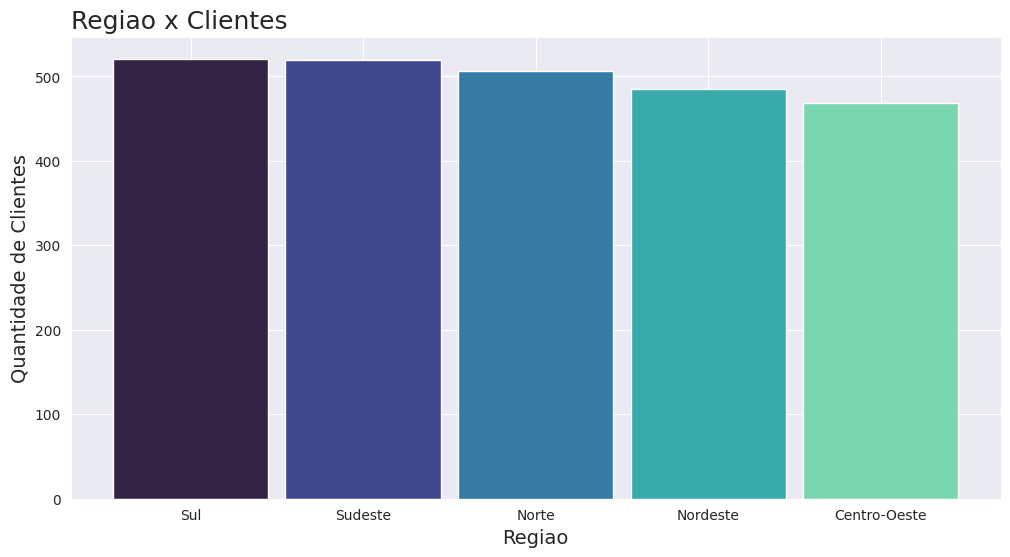

In [ ]:
# Ordenar os dados do maior para o menor número médio de clientes por região
df_regiao_clientes = df_regiao_clientes.sort_values(by="count", ascending=False)

#Tamanho da Figura
plt.figure(figsize=(12,6))

#Paleta de Cores
Paleta_Cores = sns.color_palette('mako', len(df_regiao_clientes) )
sns.set_style('darkgrid')

#Plotagem
plt.bar(df_regiao_clientes['regiao_cliente'],
        df_regiao_clientes['count'],
        width=0.9,
        color = Paleta_Cores
        )

#Titulo
plt.title('Regiao x Clientes', loc = 'left', fontsize = 18)

#Labels
plt.xlabel('Regiao', fontsize = 14)
plt.ylabel('Quantidade de Clientes', fontsize = 14)
plt.xticks(rotation = 0);

In [ ]:
df_desafio_nps_fase_1['regiao_cliente'].value_counts().mean()

np.float64(500.0)

## 📊🔍Base de dados está distribuída de maneira uniforme pelas regiões do país, um total por região variando entre 468 e 521 clientes resultando numa média de 500 clientes considerando todas as regiões.

#**4.2** Média de idade dos clientes por região

In [ ]:
df_regiao_idade = pd.DataFrame(df_desafio_nps_fase_1.groupby('regiao_cliente')[['idade_cliente']].mean().round(1)).reset_index()

In [ ]:
df_regiao_idade

,regiao_cliente,idade_cliente
0,Centro-Oeste,43.4
1,Nordeste,44.0
2,Norte,43.4
3,Sudeste,42.9
4,Sul,43.3


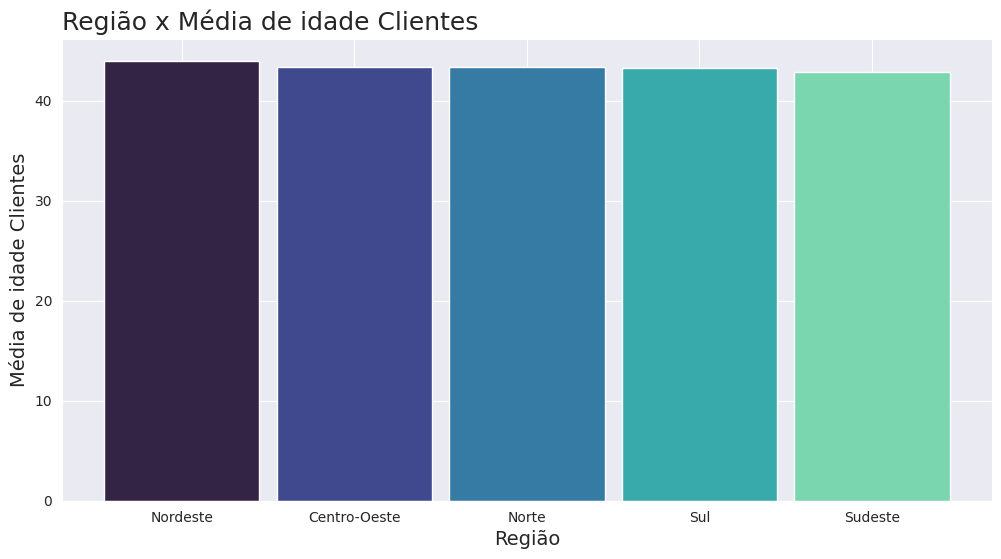

In [ ]:
# Ordenar os dados da maior para a menor média de idade de clientes por região
df_regiao_idade = df_regiao_idade.sort_values(by="idade_cliente", ascending=False)

#Tamanho da Figura
plt.figure(figsize=(12,6))

#Paleta de Cores
Paleta_Cores = sns.color_palette('mako', len(df_regiao_idade) )
sns.set_style('darkgrid')

#Plotagem
plt.bar(df_regiao_idade['regiao_cliente'],
        df_regiao_idade['idade_cliente'],
        width=0.9,
        color = Paleta_Cores
        )

#Titulo
plt.title('Região x Média de idade Clientes', loc = 'left', fontsize = 18)

#Labels
plt.xlabel('Região', fontsize = 14)
plt.ylabel('Média de idade Clientes', fontsize = 14)
plt.xticks(rotation = 0);

In [ ]:
df_desafio_nps_fase_1['idade_cliente'].mean()

np.float64(43.396)

## 📊🔍Base de dados de clientes está distribuída de maneira uniforme considerando a média de idade dos clientes dentro das regiões do país, variando entre 42 e 44 anos de média de idade por região, e 43 anos de média de idade em toda a base de dados sendo trabalhada.

#**4.3** Média de tempo de relacionamento dos clientes por região

In [ ]:
df_regiao_tempo_relacionamento = pd.DataFrame(df_desafio_nps_fase_1.groupby('regiao_cliente')[['tempo_relacionamento_cliente_meses']].mean().round(1)).reset_index()

In [ ]:
df_regiao_tempo_relacionamento

,regiao_cliente,tempo_relacionamento_cliente_meses
0,Centro-Oeste,61.2
1,Nordeste,59.8
2,Norte,61.6
3,Sudeste,61.9
4,Sul,62.0


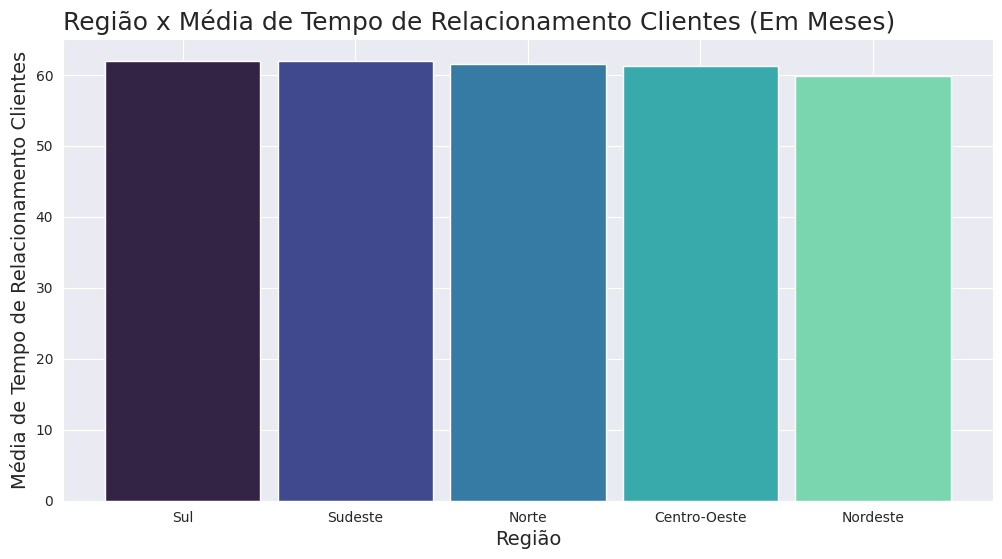

In [ ]:
# Ordenar os dados da maior para a menor média de tempo de relacionamento de clientes por região
df_regiao_tempo_relacionamento = df_regiao_tempo_relacionamento.sort_values(by="tempo_relacionamento_cliente_meses", ascending=False)

#Tamanho da Figura
plt.figure(figsize=(12,6))

#Paleta de Cores
Paleta_Cores = sns.color_palette('mako', len(df_regiao_tempo_relacionamento) )
sns.set_style('darkgrid')

#Plotagem
plt.bar(df_regiao_tempo_relacionamento['regiao_cliente'],
        df_regiao_tempo_relacionamento['tempo_relacionamento_cliente_meses'],
        width=0.9,
        color = Paleta_Cores
        )

#Titulo
plt.title('Região x Média de Tempo de Relacionamento Clientes (Em Meses)', loc = 'left', fontsize = 18)

#Labels
plt.xlabel('Região', fontsize = 14)
plt.ylabel('Média de Tempo de Relacionamento Clientes', fontsize = 14)
plt.xticks(rotation = 0);

In [ ]:
df_desafio_nps_fase_1['tempo_relacionamento_cliente_meses'].mean()

np.float64(61.3224)

## 📊🔍Base de dados está distribuída de maneira uniforme pela media do tempo de relacionamento dos clientes dentro das regiões do país, variando entre 59 e 62 anos de média de idade por região, e 61 anos de média do tempo de relacionamento em toda a base de dados sendo trabalhada.

#**4.4** Média do valor do pedido dos clientes por região

In [ ]:
df_regiao_valor_pedido = pd.DataFrame(df_desafio_nps_fase_1.groupby('regiao_cliente')[['valor_pedido']].mean().round(2)).reset_index()

In [ ]:
df_regiao_valor_pedido

,regiao_cliente,valor_pedido
0,Centro-Oeste,444.66
1,Nordeste,443.62
2,Norte,434.57
3,Sudeste,413.53
4,Sul,436.58


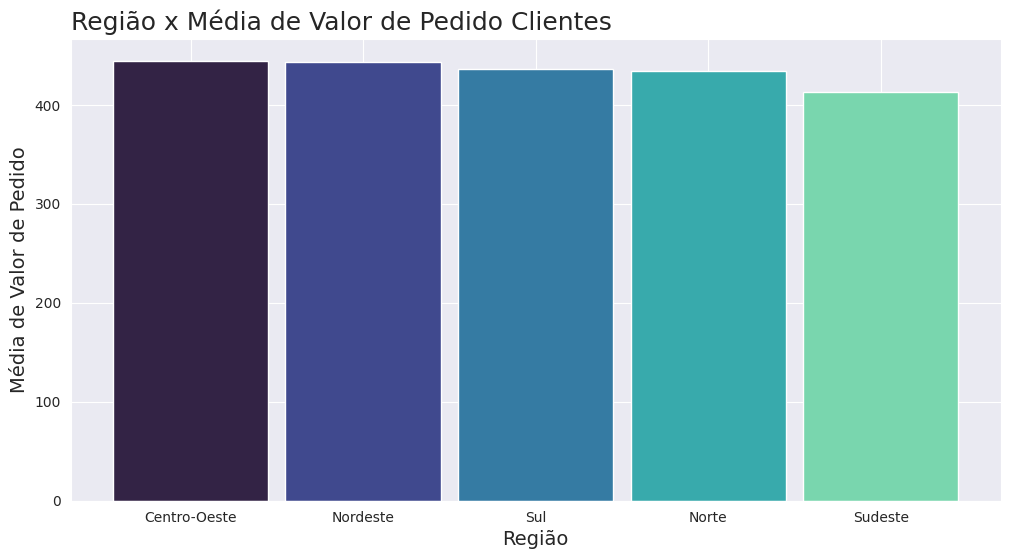

In [ ]:
# Ordenar os dados da maior para a menor média de valor de pedido de clientes por região
df_regiao_valor_pedido = df_regiao_valor_pedido.sort_values(by="valor_pedido", ascending=False)

#Tamanho da Figura
plt.figure(figsize=(12,6))

#Paleta de Cores
Paleta_Cores = sns.color_palette('mako', len(df_regiao_valor_pedido) )
sns.set_style('darkgrid')

#Plotagem
plt.bar(df_regiao_valor_pedido['regiao_cliente'],
        df_regiao_valor_pedido['valor_pedido'],
        width=0.9,
        color = Paleta_Cores
        )

#Titulo
plt.title('Região x Média de Valor de Pedido Clientes', loc = 'left', fontsize = 18)

#Labels
plt.xlabel('Região', fontsize = 14)
plt.ylabel('Média de Valor de Pedido', fontsize = 14)
plt.xticks(rotation = 0);

In [ ]:
df_desafio_nps_fase_1['valor_pedido'].mean()

np.float64(434.25974)

## 📊🔍Base de dados está distribuída de maneira uniforme pelo valor medio de pedidos dos clientes dentro das regiões do país, variando entre 413 e 444 o valor médio de cada pedido por região, e valor médio de 434 por pedido em toda a base de dados sendo trabalhada.

## 🧠🔍Não há evidência de desbalanceamento significativo entre as categorias de região nos quesitos:  

*   Quantidade de clientes por região
*   Média de idade os clientes por região  
*   Média de tempo de relacionamento dos clientes por região
*   Média dos valores de pedido dos clientes por região.

##Para todos esses quesitos, a base dade de dados apresenta uma distribuição praticamente uniforme/balanceada.


## 📊🔍Nas células seguintes serão feitas análises considerando as médias de pontuação NPS por Região, Faixa Etária, intervalos de tempo de relacionamento e faixas de valor de pedido visando identificar tipos/caracteristicas de clientes versus pontuação NPS.

In [ ]:
df_regiao_pontuacao_nps = pd.DataFrame(df_desafio_nps_fase_1.groupby('regiao_cliente')[['pontuacao_nps']].mean().round(1)).reset_index()

In [ ]:
df_regiao_pontuacao_nps

,regiao_cliente,pontuacao_nps
0,Centro-Oeste,4.2
1,Nordeste,4.4
2,Norte,4.4
3,Sudeste,4.4
4,Sul,4.5


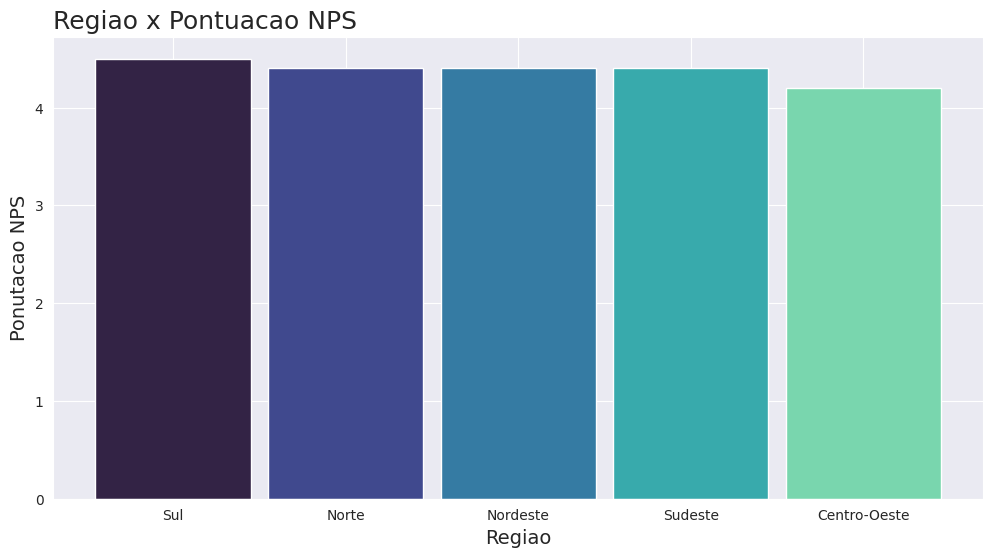

In [ ]:
# Ordenar os dados da maior para a menor pontuação_nps por região
df_regiao_pontuacao_nps = df_regiao_pontuacao_nps.sort_values(by="pontuacao_nps", ascending=False)

#Tamanho da Figura
plt.figure(figsize=(12,6))

#Paleta de Cores
Paleta_Cores = sns.color_palette('mako', len(df_regiao_pontuacao_nps) )
sns.set_style('darkgrid')

#Plotagem
plt.bar(df_regiao_pontuacao_nps['regiao_cliente'],
        df_regiao_pontuacao_nps['pontuacao_nps'],
        width=0.9,
        color = Paleta_Cores
        )

#Titulo
plt.title('Regiao x Pontuacao NPS', loc = 'left', fontsize = 18)

#Labels
plt.xlabel('Regiao', fontsize = 14)
plt.ylabel('Ponutacao NPS', fontsize = 14)
plt.xticks(rotation = 0);

In [ ]:
# Criar as faixas etárias
bins = [0, 20, 30, 40, 50, 60, float('inf')]
labels = [
    'Até 20',
    '21-30',
    '31-40',
    '41-50',
    '51-60',
    '60+'
]

df_desafio_nps_fase_1['faixa_etaria'] = pd.cut(
    df_desafio_nps_fase_1['idade_cliente'],
    bins=bins,
    labels=labels
)

# Agrupar e calcular média de NPS
df_faixa_nps = (
    df_desafio_nps_fase_1
    .groupby('faixa_etaria')[['pontuacao_nps']]
    .mean()
    .round(1)
    .reset_index()
)



In [ ]:
df_faixa_nps

,faixa_etaria,pontuacao_nps
0,Até 20,4.3
1,21-30,4.6
2,31-40,4.2
3,41-50,4.3
4,51-60,4.3
5,60+,4.6


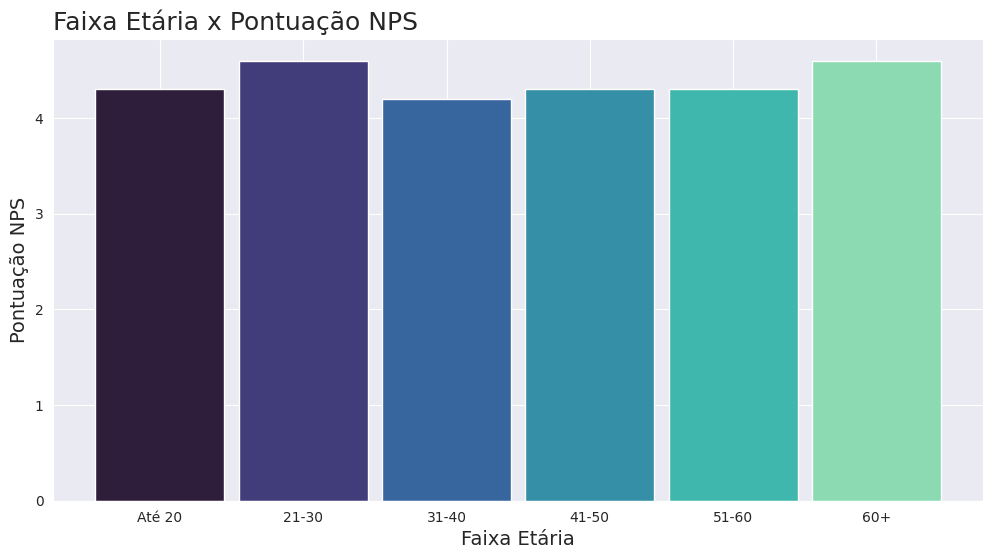

In [ ]:
# Garantir ordenação correta das faixas
ordem = ['Até 20', '21-30', '31-40', '41-50', '51-60', '60+']

df_faixa_nps['faixa_etaria'] = pd.Categorical(
    df_faixa_nps['faixa_etaria'],
    categories=ordem,
    ordered=True
)

df_faixa_nps = df_faixa_nps.sort_values('faixa_etaria')

# Tamanho da figura
plt.figure(figsize=(12,6))

# Paleta de cores (corrigido: usar df_faixa_nps)
Paleta_Cores = sns.color_palette('mako', len(df_faixa_nps))
sns.set_style('darkgrid')

# Plotagem
plt.bar(
    df_faixa_nps['faixa_etaria'],
    df_faixa_nps['pontuacao_nps'],
    width=0.9,
    color=Paleta_Cores
)

# Título e labels
plt.title('Faixa Etária x Pontuação NPS', loc='left', fontsize=18)
plt.xlabel('Faixa Etária', fontsize=14)
plt.ylabel('Pontuação NPS', fontsize=14)

plt.xticks(rotation=0)

plt.show()

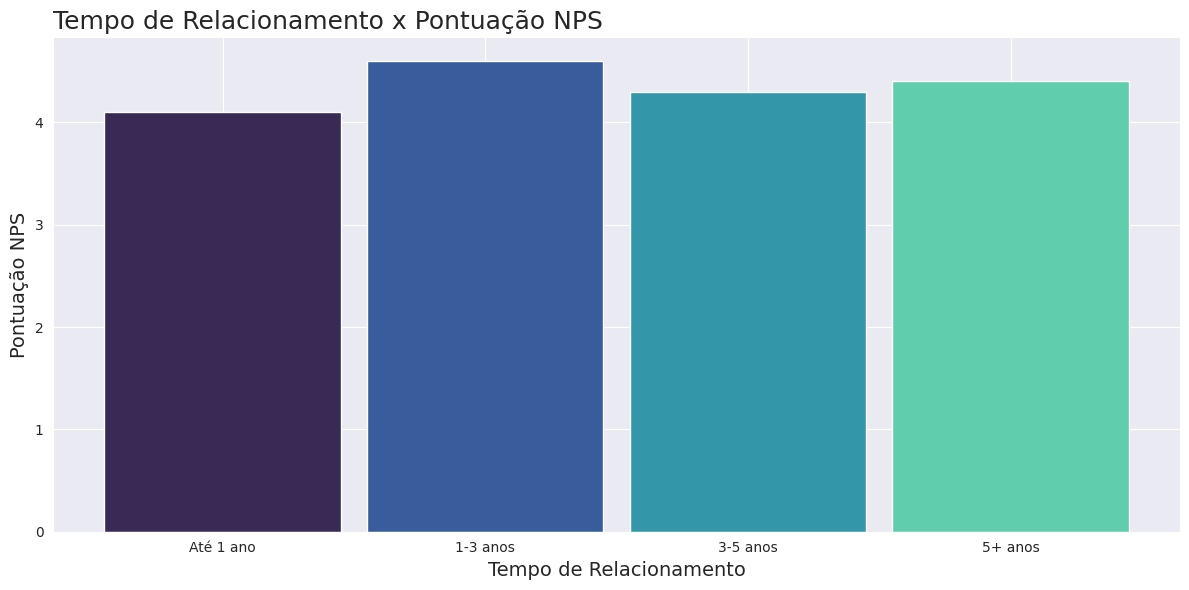

In [ ]:
# =========================
# 1. Criar faixas de relacionamento (em meses → anos)
# =========================

bins = [0, 12, 36, 60, float('inf')]
labels = ['Até 1 ano', '1-3 anos', '3-5 anos', '5+ anos']

df_desafio_nps_fase_1['faixa_relacionamento'] = pd.cut(
    df_desafio_nps_fase_1['tempo_relacionamento_cliente_meses'],
    bins=bins,
    labels=labels,
    ordered=True
)

# =========================
# 2. Agrupar e calcular média de NPS
# =========================

df_rel_nps = (
    df_desafio_nps_fase_1
    .groupby('faixa_relacionamento')[['pontuacao_nps']]
    .mean()
    .round(1)
    .reset_index()
)

# =========================
# 3. Garantir ordenação correta
# =========================

ordem = ['Até 1 ano', '1-3 anos', '3-5 anos', '5+ anos']

df_rel_nps['faixa_relacionamento'] = pd.Categorical(
    df_rel_nps['faixa_relacionamento'],
    categories=ordem,
    ordered=True
)

df_rel_nps = df_rel_nps.sort_values('faixa_relacionamento')

# =========================
# 4. Plotar gráfico
# =========================

plt.figure(figsize=(12, 6))

# Paleta de cores
sns.set_style('darkgrid')
Paleta_Cores = sns.color_palette('mako', len(df_rel_nps))

# Gráfico de barras
plt.bar(
    df_rel_nps['faixa_relacionamento'],
    df_rel_nps['pontuacao_nps'],
    color=Paleta_Cores,
    width=0.9
)

# Títulos e labels
plt.title('Tempo de Relacionamento x Pontuação NPS', loc='left', fontsize=18)
plt.xlabel('Tempo de Relacionamento', fontsize=14)
plt.ylabel('Pontuação NPS', fontsize=14)

# Ajustes finais
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

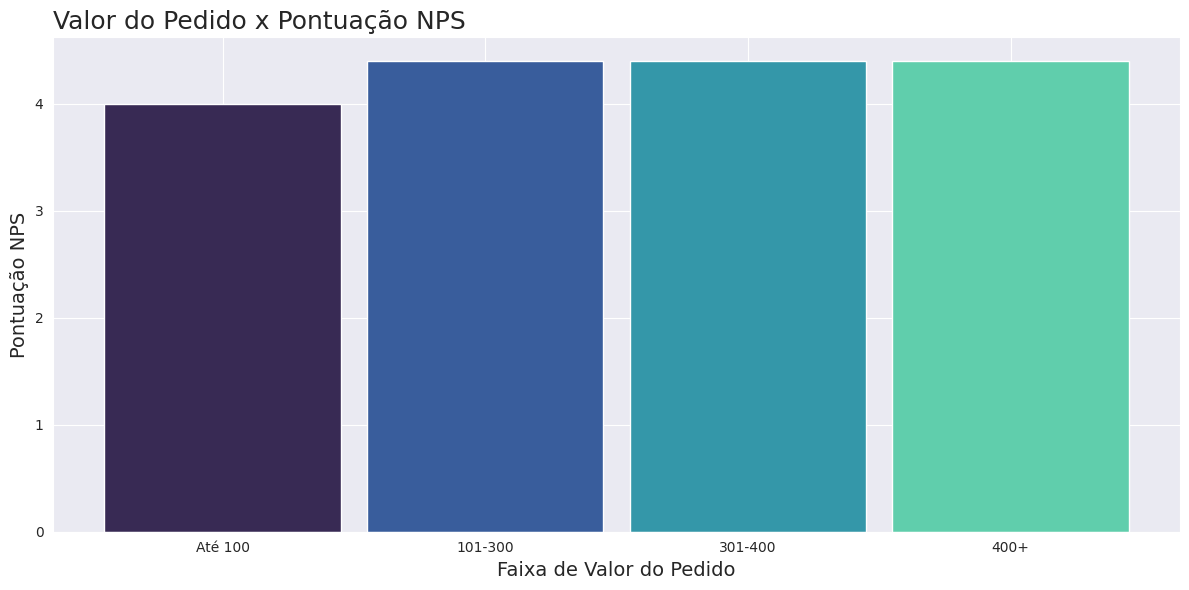

In [ ]:
# =========================
# 1. Criar faixas de valor do pedido
# =========================

bins = [0, 100, 300, 400, float('inf')]
labels = ['Até 100', '101-300', '301-400', '400+']

df_desafio_nps_fase_1['faixa_valor_pedido'] = pd.cut(
    df_desafio_nps_fase_1['valor_pedido'],
    bins=bins,
    labels=labels,
    ordered=True
)

# =========================
# 2. Agrupar e calcular média de NPS
# =========================

df_valor_nps = (
    df_desafio_nps_fase_1
    .groupby('faixa_valor_pedido')[['pontuacao_nps']]
    .mean()
    .round(1)
    .reset_index()
)

# =========================
# 3. Garantir ordenação correta
# =========================

ordem = ['Até 100', '101-300', '301-400', '400+']

df_valor_nps['faixa_valor_pedido'] = pd.Categorical(
    df_valor_nps['faixa_valor_pedido'],
    categories=ordem,
    ordered=True
)

df_valor_nps = df_valor_nps.sort_values('faixa_valor_pedido')

# =========================
# 4. Plotar gráfico
# =========================

plt.figure(figsize=(12, 6))

sns.set_style('darkgrid')
Paleta_Cores = sns.color_palette('mako', len(df_valor_nps))

plt.bar(
    df_valor_nps['faixa_valor_pedido'],
    df_valor_nps['pontuacao_nps'],
    color=Paleta_Cores,
    width=0.9
)

plt.title('Valor do Pedido x Pontuação NPS', loc='left', fontsize=18)
plt.xlabel('Faixa de Valor do Pedido', fontsize=14)
plt.ylabel('Pontuação NPS', fontsize=14)

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

## 🧠🔍As médias das pontuações NPS nas perspectivas:  

Regiao ( menor media na região centro-oeste )  
Idade ( menor média na faixa etária dos 31-40 anos )  
Tempo de relacionamento ( menor média em clientes há menos de 1 ano )  
Valor do pedido ( menor média na faixa de valor até 100 )  

Mas por serem diferenças bem discretas não há como inferir que existe um perfil de cliente que possa ser categorizado com tendência a menor pontuação de NPS

#**5**.Aplicando a abordagem one-hot encoding para a coluna "regiao_cliente" para facilitar eventuais aplicações de modelos preditivos matemáticos ( conforme comentado anteriormente neste notebook )

In [ ]:
df_desafio_nps_fase_1 = pd.get_dummies(df_desafio_nps_fase_1, columns=["regiao_cliente"], prefix="regiao")

In [ ]:
df_desafio_nps_fase_1.head()

,id_cliente,idade_cliente,tempo_relacionamento_cliente_meses,id_pedido,valor_pedido,quantidade_itens,valor_desconto,numero_parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,...,quantidade_reclamacoes,pontuacao_satisfacao_interna,faixa_etaria,faixa_relacionamento,faixa_valor_pedido,regiao_Centro-Oeste,regiao_Nordeste,regiao_Norte,regiao_Sudeste,regiao_Sul
0,1,63,14,50001,139.73,4,39.35,4,2,2,...,3,6.5,60+,1-3 anos,101-300,False,True,False,False,False
1,2,20,1,50002,458.95,2,9.51,10,6,4,...,3,0.0,Até 20,Até 1 ano,400+,False,False,False,False,True
2,3,46,111,50003,507.06,5,42.82,6,6,1,...,7,1.5,41-50,5+ anos,400+,False,True,False,False,False
3,4,52,117,50004,302.19,2,19.58,9,5,2,...,4,0.3,51-60,5+ anos,301-400,True,False,False,False,False
4,5,56,50,50005,253.06,1,29.37,11,13,1,...,3,7.9,51-60,3-5 anos,101-300,False,False,True,False,False


In [ ]:
df_desafio_nps_fase_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 26 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   id_cliente                          2500 non-null   int64   
 1   idade_cliente                       2500 non-null   int64   
 2   tempo_relacionamento_cliente_meses  2500 non-null   int64   
 3   id_pedido                           2500 non-null   int64   
 4   valor_pedido                        2500 non-null   float64 
 5   quantidade_itens                    2500 non-null   int64   
 6   valor_desconto                      2500 non-null   float64 
 7   numero_parcelas_pagamento           2500 non-null   int64   
 8   tempo_entrega_dias                  2500 non-null   int64   
 9   atraso_entrega_dias                 2500 non-null   int64   
 10  valor_frete                         2500 non-null   float64 
 11  tentativas_entrega            

## 🚀🔍Abordagem "ONE-HOT ENCODING" foi aplicada com sucesso

#**6**.Análise de possíveis correlações entre as colunas

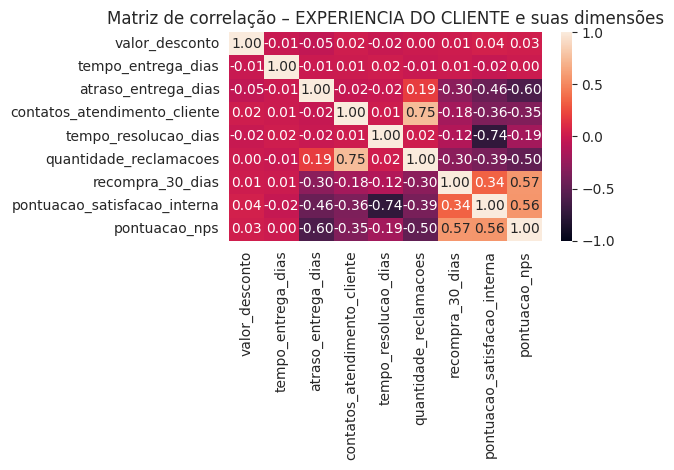

In [ ]:
cols_corr = [c for c in ["valor_desconto", "tempo_entrega_dias", "atraso_entrega_dias", "contatos_atendimento_cliente", "tempo_resolucao_dias", "quantidade_reclamacoes", "recompra_30_dias", "pontuacao_satisfacao_interna", "pontuacao_nps" ] if c in df_desafio_nps_fase_1.columns]
corr = df_desafio_nps_fase_1[cols_corr].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1)
plt.title("Matriz de correlação – EXPERIENCIA DO CLIENTE e suas dimensões")
plt.tight_layout()
plt.show()

## 🧠🔍Considerando que correlação é diferente de causalidade e considerando as matrizes de correlacionamento acima, é possível inferir que existe um efeito indireto forte nas sequencias:

##tempo_resolucao → satisfação interna → NPS  

Ou seja:

1.   tempo de resolução impacta consideravelmente a satisfação
2.   satisfação impacta o NPS

##atraso_entrega_dias → satisfação interna → NPS  

Ou seja:

1.   atraso da entrega impacta tambem a satisfação
2.   satisfação impacta o NPS

##👉 Ambas são cadeias causais possíveis


#**7**.Análise de causalidade entre as correlações mais fortes



#**7.1** Análise aprofundada das sequência "tempo_resolucao_dias" => pontuacao_satisfacao_interna" => "pontuacao_nps"  



In [ ]:
df_desafio_nps_fase_1['pontuacao_satisfacao_interna'].describe()

,pontuacao_satisfacao_interna
count,2500.000000
mean,2.941600
std,2.378957
min,0.000000
25%,0.700000
50%,2.800000
75%,4.800000
max,10.000000


In [ ]:
(df_desafio_nps_fase_1['pontuacao_satisfacao_interna'] < 1).sum()

np.int64(694)

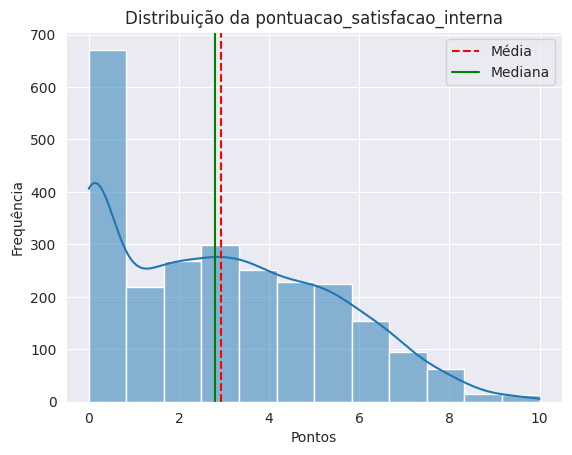

In [ ]:
sns.histplot(
    df_desafio_nps_fase_1['pontuacao_satisfacao_interna'],
    bins=12,
    kde=True  # adiciona a curva de densidade
)

plt.axvline(df_desafio_nps_fase_1['pontuacao_satisfacao_interna'].mean(), color='red', linestyle='--', label='Média')
plt.axvline(df_desafio_nps_fase_1['pontuacao_satisfacao_interna'].median(), color='green', linestyle='-', label='Mediana')

plt.legend()
plt.title('Distribuição da pontuacao_satisfacao_interna')
plt.xlabel('Pontos')
plt.ylabel('Frequência')

plt.show()

## 🚨Chama a atenção é que há um conjunto considerável de clientes na base de dados que possui a variável "pontuacao_satisfacao_interna" com pontuacao menor que 1(um) ( esses dados são reais ou são dados inconsistentes ? )  

##Nesse caso caberia verificar com usuários-chave da área de negócios e/ou "data owners" para verificar se seriam casos reais.

In [ ]:
df_desafio_nps_fase_1['pontuacao_nps'].describe()

,pontuacao_nps
count,2500.000000
mean,4.378600
std,2.510229
min,0.000000
25%,2.600000
50%,4.400000
75%,6.100000
max,10.000000


In [ ]:
(df_desafio_nps_fase_1['pontuacao_nps'] < 1).sum()

np.int64(272)

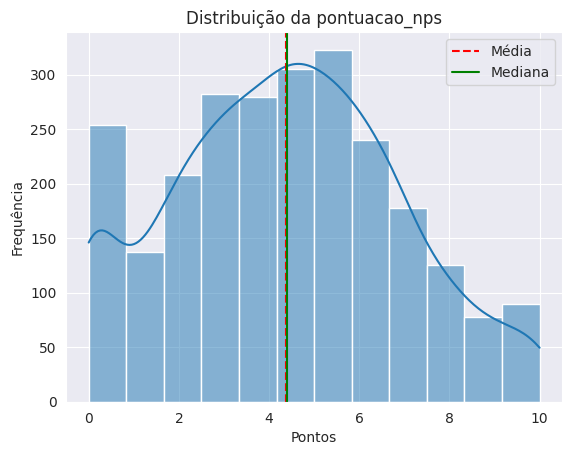

In [ ]:
sns.histplot(
    df_desafio_nps_fase_1['pontuacao_nps'],
    bins=12,
    kde=True  # adiciona a curva de densidade
)

plt.axvline(df_desafio_nps_fase_1['pontuacao_nps'].mean(), color='red', linestyle='--', label='Média')
plt.axvline(df_desafio_nps_fase_1['pontuacao_nps'].median(), color='green', linestyle='-', label='Mediana')

plt.legend()
plt.title('Distribuição da pontuacao_nps')
plt.xlabel('Pontos')
plt.ylabel('Frequência')

plt.show()

## 🚨No caso da variável "pontuacao_nps" temos menos casos com pontuação menor do que 1(um) do que a variável pontuacao_satisfacao_interna, mas mesmo assim também há um conjunto de clientes com pontuacao NPS bem baixa.

##Nesse caso também caberia verificar com usuários-chave da área de negócios e/ou "data owners" para verificar se seriam casos reais ou seria algum dado inconsistente

##Mas outro ponto que podemos observar nesse gráfico acima é que a maior concentração de clientes está nas categorias "detratores e neutros" , considerando a seguinte categorização a partir da pontuação NPS:

Pontuação NPS na escala (0 a 10)  

Detrator (0–6)  
Neutro (7–8)  
Promotor (9–10)  

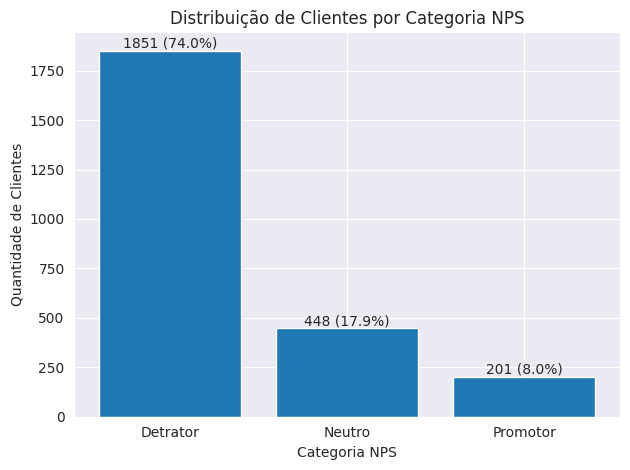

In [ ]:
def classificar_nps(x):
    if x <= 6:
        return 'Detrator'
    elif x <= 8:
        return 'Neutro'
    else:
        return 'Promotor'

df_desafio_nps_fase_1['categoria_nps'] = df_desafio_nps_fase_1['pontuacao_nps'].apply(classificar_nps)
df_desafio_nps_fase_1['categoria_nps'].value_counts()

# Ordem correta
ordem = ['Detrator', 'Neutro', 'Promotor']

# =========================================
# Frequência e percentual
# =========================================

freq = df_desafio_nps_fase_1['categoria_nps'] \
    .value_counts() \
    .reindex(ordem, fill_value=0)

perc = df_desafio_nps_fase_1['categoria_nps'] \
    .value_counts(normalize=True) \
    .reindex(ordem, fill_value=0) * 100

# =========================================
# Gráfico
# =========================================

fig, ax = plt.subplots()

bars = ax.bar(freq.index, freq.values)

# Labels (quantidade + %)
for i, bar in enumerate(bars):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{freq.iloc[i]} ({perc.iloc[i]:.1f}%)',
        ha='center',
        va='bottom'
    )

# Títulos
ax.set_title('Distribuição de Clientes por Categoria NPS')
ax.set_ylabel('Quantidade de Clientes')
ax.set_xlabel('Categoria NPS')

plt.tight_layout()
plt.show()

## ⚠️🔍NPS categorizado em Detratores, Neutros e Promotores para transformar uma variável contínua em uma métrica de negócio acionável.

##Através da distribuição percentual podemos identificar visualmente riscos (detratores) e oportunidades (neutros).”

Reforçando observação anterior:  

Há um conjunto de clientes com pontuacao NPS menor do que 1(um) que precisa ser validado com a área de negócios para entender se são casos reais de nota reais a partir do feedback dos clientes ou se são casos faltantes/inconsistentes por não ter havido manifestação dos clientes no pós-venda ou por outro motivo. Se for o caso de não ter tido feedback dos clientes talvez uma abordagem seria trata-los na categoria "neutro".

In [ ]:
df_desafio_nps_fase_1['tempo_resolucao_dias'].describe()

,tempo_resolucao_dias
count,2500.000000
mean,5.485600
std,3.458002
min,0.000000
25%,2.000000
50%,6.000000
75%,8.000000
max,11.000000


## 🚨A variável tempo_resolucao_dias varia de 0 a 11 dias, com média e mediana próximas, indicando uma distribuição aproximadamente simétrica, com a maior concentração de valores entre 2 e 8 dias.  

##Pontos de atenção:  

O valor 0(zero) dias merece validação:  

faz sentido no negócio?  
Seriam casos de resolução imediata antes de fechar 1(um) dia de tempo de resolução ?  
ou pode ser erro / default?  

O desvio padrão não é pequeno → há variabilidade considerável

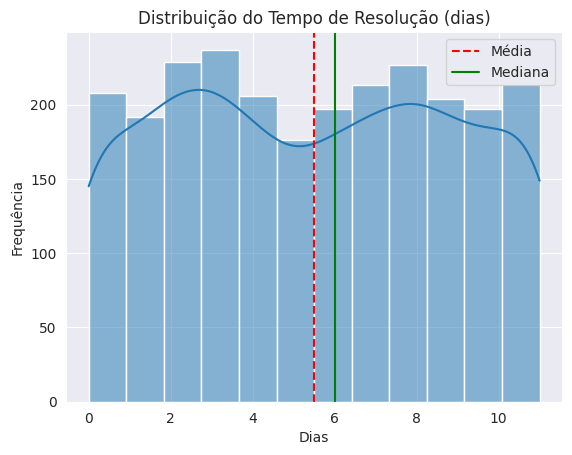

In [ ]:
sns.histplot(
    df_desafio_nps_fase_1['tempo_resolucao_dias'],
    bins=12,
    kde=True  # adiciona a curva de densidade
)

plt.axvline(df_desafio_nps_fase_1['tempo_resolucao_dias'].mean(), color='red', linestyle='--', label='Média')
plt.axvline(df_desafio_nps_fase_1['tempo_resolucao_dias'].median(), color='green', linestyle='-', label='Mediana')

plt.legend()
plt.title('Distribuição do Tempo de Resolução (dias)')
plt.xlabel('Dias')
plt.ylabel('Frequência')

plt.show()

## 🧠🔍Curvas similares a uma distribuição normal para as variáveis **"tempo_resolucao_dias"** , **"pontuacao_satisfacao_interna"** e **"pontuacao_nps"** ( curvas em forma de sino = curva de Gauss )

In [ ]:
(df_desafio_nps_fase_1['tempo_resolucao_dias'] == 0).sum()

np.int64(208)

In [ ]:
df_desafio_nps_fase_1.groupby(
    df_desafio_nps_fase_1['tempo_resolucao_dias'] == 0
)['pontuacao_satisfacao_interna'].mean()

,pontuacao_satisfacao_interna
tempo_resolucao_dias,
False,2.680541
True,5.818269


In [ ]:
df_desafio_nps_fase_1.groupby(
    df_desafio_nps_fase_1['tempo_resolucao_dias'] == 0
)['pontuacao_nps'].mean()

,pontuacao_nps
tempo_resolucao_dias,
False,4.293150
True,5.320192


## 🧠🔍Podemos inferir que atendimentos resolvidos no mesmo dia apresentam níveis significativamente mais altos de satisfação interna e também maior NPS, indicando que a rapidez na resolução de problemas enfrentados pelos clientes é um fator crítico para a experiência do cliente.

In [ ]:
(df_desafio_nps_fase_1['tempo_resolucao_dias'] == 11).sum()

np.int64(214)

In [ ]:
df_desafio_nps_fase_1.groupby(
    df_desafio_nps_fase_1['tempo_resolucao_dias'] == 11
)['pontuacao_satisfacao_interna'].mean()

,pontuacao_satisfacao_interna
tempo_resolucao_dias,
False,3.171391
True,0.486916


In [ ]:
df_desafio_nps_fase_1.groupby(
    df_desafio_nps_fase_1['tempo_resolucao_dias'] == 11
)['pontuacao_nps'].mean()

,pontuacao_nps
tempo_resolucao_dias,
False,4.444007
True,3.679907


## 🧠🔍Podemos inferir, analisando o outro extremo ( 11 dias de tempo de resolução ), níveis extremamente baixos de satisfação, indicando forte impacto negativo da demora na experiência do cliente.

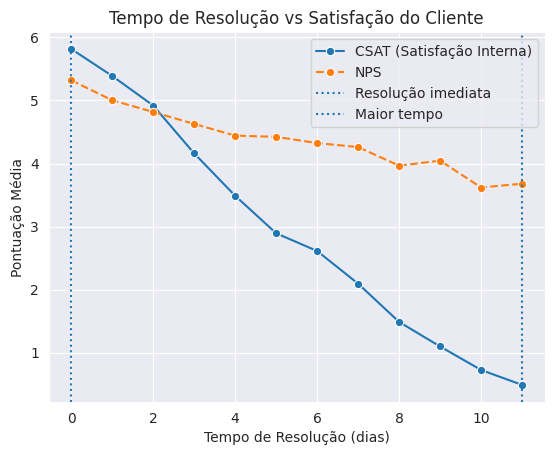

In [ ]:
# Agrupando os dados
df_plot = df_desafio_nps_fase_1.groupby('tempo_resolucao_dias', as_index=False)[
    ['pontuacao_satisfacao_interna', 'pontuacao_nps']
].mean()

# Criando o gráfico
plt.figure()

sns.lineplot(
    data=df_plot,
    x='tempo_resolucao_dias',
    y='pontuacao_satisfacao_interna',
    marker='o',
    label='CSAT (Satisfação Interna)'
)

sns.lineplot(
    data=df_plot,
    x='tempo_resolucao_dias',
    y='pontuacao_nps',
    marker='o',
    linestyle='--',
    label='NPS'
)

plt.title('Tempo de Resolução vs Satisfação do Cliente')
plt.xlabel('Tempo de Resolução (dias)')
plt.ylabel('Pontuação Média')
plt.axvline(0, linestyle=':', label='Resolução imediata')
plt.axvline(11, linestyle=':', label='Maior tempo')

plt.legend()

plt.show()

## 🧠🔍Linhas descendentes de pontuação na medida que o tempo de resolução aumenta  
Queda mais acentuada no CSAT  
NPS caindo mais suavemente mas refletindo impacto da insatisfação

## 🚨Pontos de atenção:  

Os zeros são reais?

Se forem erro:

o insight é falso

Se forem reais:

insight é fortíssimo  

Exemplo:

casos simples → resolvem no mesmo dia → maior satisfação  
casos complexos → demoram → menor satisfação

#**7.2** Análise aprofundada das sequência "atraso_entrega_dias" => pontuacao_satisfacao_interna" => "pontuacao_nps"  

In [ ]:
df_desafio_nps_fase_1['atraso_entrega_dias'].describe()

,atraso_entrega_dias
count,2500.000000
mean,2.187200
std,1.454442
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,8.000000


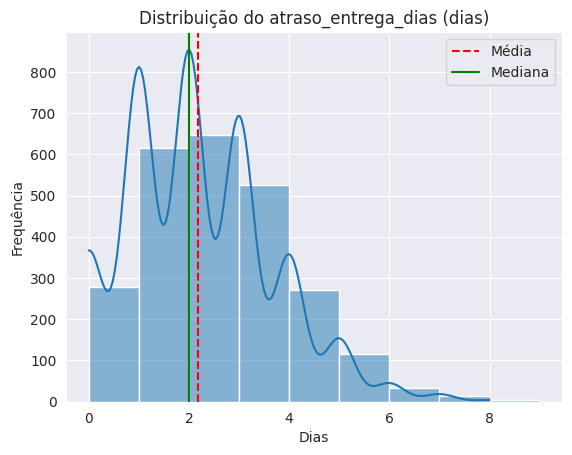

In [ ]:
bins = np.arange(
    df_desafio_nps_fase_1['atraso_entrega_dias'].min(),
    df_desafio_nps_fase_1['atraso_entrega_dias'].max() + 2
)

sns.histplot(
    df_desafio_nps_fase_1['atraso_entrega_dias'],
    bins=bins,
    kde=True
)

plt.axvline(df_desafio_nps_fase_1['atraso_entrega_dias'].mean(), color='red', linestyle='--', label='Média')
plt.axvline(df_desafio_nps_fase_1['atraso_entrega_dias'].median(), color='green', linestyle='-', label='Mediana')

plt.legend()
plt.title('Distribuição do atraso_entrega_dias (dias)')
plt.xlabel('Dias')
plt.ylabel('Frequência')

plt.show()

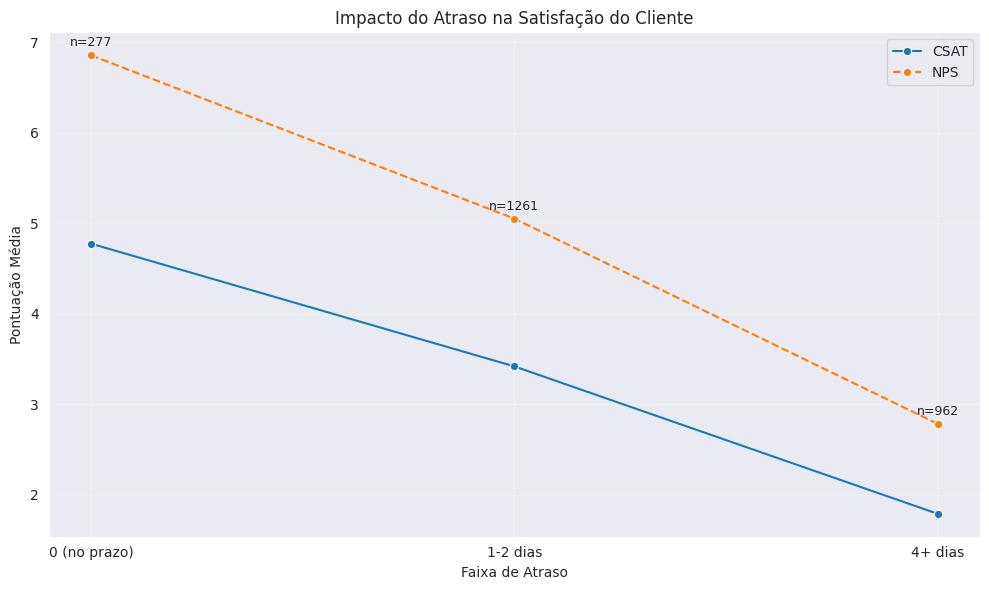

In [ ]:
# =========================================
# 1. Criar faixas de atraso (ajustado)
# =========================================

df_desafio_nps_fase_1['faixa_atraso'] = pd.cut(
    df_desafio_nps_fase_1['atraso_entrega_dias'],
    bins=[-1, 0, 2, float('inf')],
    labels=['0 (no prazo)', '1-2 dias', '4+ dias']
)

# =========================================
# 2. Agrupar métricas
# =========================================

df_plot = df_desafio_nps_fase_1.groupby('faixa_atraso', as_index=False)[
    ['pontuacao_satisfacao_interna', 'pontuacao_nps']
].mean()

# Volume por faixa
df_volume = df_desafio_nps_fase_1.groupby('faixa_atraso').size().reset_index(name='volume')

# Merge
df_plot = df_plot.merge(df_volume, on='faixa_atraso')

# =========================================
# 3. Gráfico
# =========================================

plt.figure(figsize=(10,6))

sns.lineplot(
    data=df_plot,
    x='faixa_atraso',
    y='pontuacao_satisfacao_interna',
    marker='o',
    label='CSAT'
)

sns.lineplot(
    data=df_plot,
    x='faixa_atraso',
    y='pontuacao_nps',
    marker='o',
    linestyle='--',
    label='NPS'
)

# =========================================
# 4. Volume no gráfico
# =========================================

for i in range(len(df_plot)):
    plt.text(
        i,
        df_plot['pontuacao_nps'][i] + 0.1,
        f"n={df_plot['volume'][i]}",
        ha='center',
        fontsize=9
    )

# =========================================
# 5. Ajustes
# =========================================

plt.title('Impacto do Atraso na Satisfação do Cliente')
plt.xlabel('Faixa de Atraso')
plt.ylabel('Pontuação Média')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 📊🧠 Insight de negócio (possíveis ações que podem ajudar a melhorar os indicadores de satistação interna refletindo no NPS

Criar SLA para reduzir o tempo de resolucao dos problemas relatados pelos clientes  
Criar SLA para reduzir o atraso nas entregas   
Monitorar casos críticos (cauda longa)  


#**8**.Analisando o questionamento da Área de Negócios:
#- Que tipo de cliente tende a ter NPS mais alto ou mais baixo?  

##Investigando mais a fundo para responder esse questionamento, a sequencia de células a seguir usa um conjunto de gráficos para avaliar o impacto da variável tempo_resolucao_dias sobre a variável "pontuacao_satisfacao_interna" ( variável "mediadora" entre tempo de resolução e pontuacao NPS ) e logo a seguir o impacto da variável atraso_entrega_dias sobre a variável "pontuacao_satisfacao_interna"

#**8.1** Avaliando o impacto da variável tempo_resolucao_dias sobre a variável "pontuacao_satisfacao_interna" ( variável "mediadora" entre tempo de resolução e pontuacao NPS )

📉 INSIGHT:
A maior queda de satisfação ocorre a partir de 3 dias
Variação: -0.76


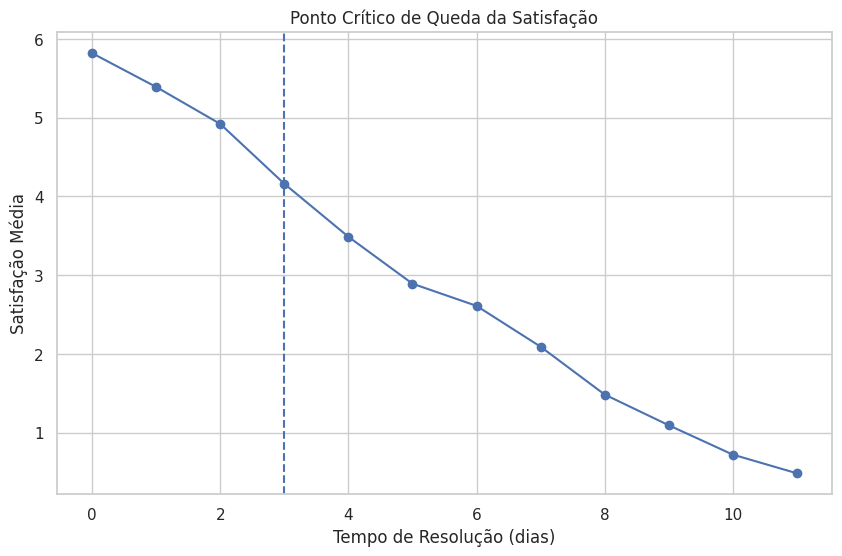

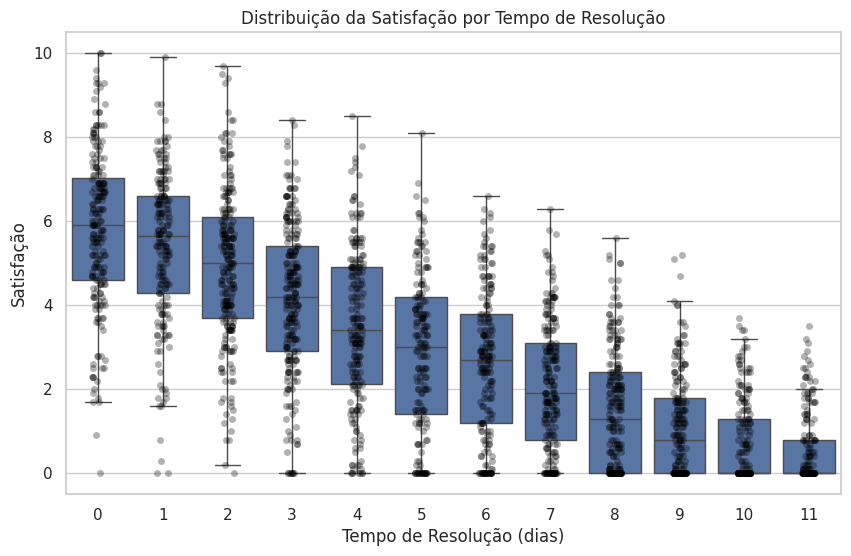

<Figure size 1000x600 with 0 Axes>

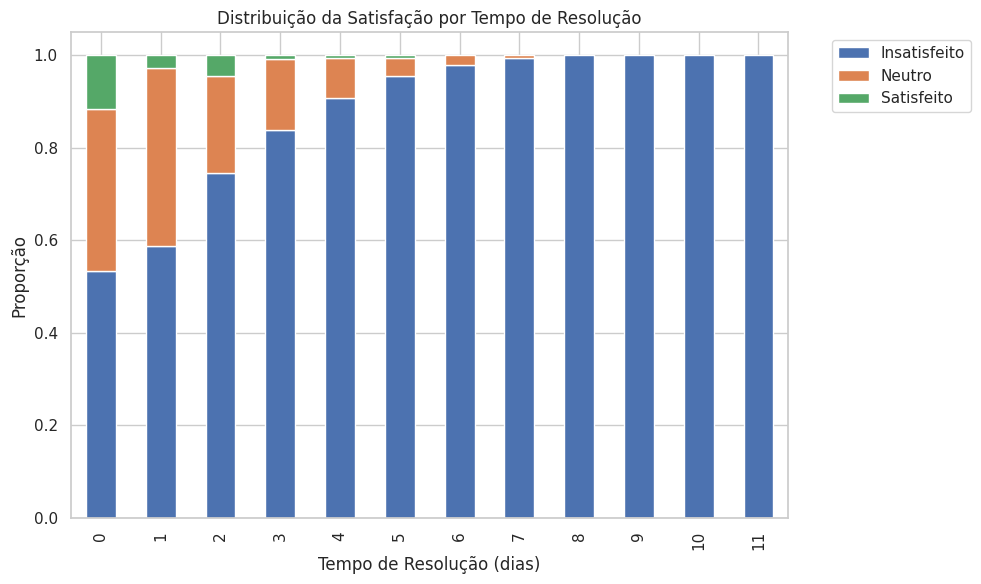

In [ ]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# =========================
# 📂 BASE
# =========================
df = df_desafio_nps_fase_1.copy()

# =========================
# 🧹 TRATAMENTO
# =========================
cols = [
    "tempo_resolucao_dias",
    "pontuacao_satisfacao_interna"
]

df = df[cols].dropna()

# =========================
# 📈 MÉDIA POR TEMPO (FALTAVA)
# =========================
df_media = df.groupby("tempo_resolucao_dias")[
    "pontuacao_satisfacao_interna"
].mean().reset_index()

# =========================
# 🔥 DETECÇÃO DO PONTO CRÍTICO
# =========================
df_media["delta"] = df_media["pontuacao_satisfacao_interna"].diff()

queda_critica = df_media.loc[df_media["delta"].idxmin()]

ponto_critico = int(queda_critica["tempo_resolucao_dias"])
queda_valor = round(queda_critica["delta"], 2)

print("📉 INSIGHT:")
print(f"A maior queda de satisfação ocorre a partir de {ponto_critico} dias")
print(f"Variação: {queda_valor}")

# =========================
# 📊 GRÁFICO COM PONTO CRÍTICO
# =========================
plt.figure()

plt.plot(
    df_media["tempo_resolucao_dias"],
    df_media["pontuacao_satisfacao_interna"],
    marker="o"
)

plt.axvline(ponto_critico, linestyle="--")

plt.title("Ponto Crítico de Queda da Satisfação")
plt.xlabel("Tempo de Resolução (dias)")
plt.ylabel("Satisfação Média")

plt.show()

# =========================
# 📦 BOXPLOT + STRIPPLOT
# =========================
plt.figure()

sns.boxplot(
    data=df,
    x="tempo_resolucao_dias",
    y="pontuacao_satisfacao_interna",
    showfliers=False
)

sns.stripplot(
    data=df,
    x="tempo_resolucao_dias",
    y="pontuacao_satisfacao_interna",
    color="black",
    alpha=0.3,
    jitter=True
)

plt.title("Distribuição da Satisfação por Tempo de Resolução")
plt.xlabel("Tempo de Resolução (dias)")
plt.ylabel("Satisfação")

plt.show()

# =========================
# 🚀 CATEGORIZAÇÃO
# =========================
def classificar_satisfacao(score):
    if score <= 6:
        return "Insatisfeito"
    elif score <= 8:
        return "Neutro"
    else:
        return "Satisfeito"

df["categoria_satisfacao"] = df["pontuacao_satisfacao_interna"].apply(classificar_satisfacao)

# =========================
# 📊 PROPORÇÃO POR TEMPO
# =========================
prop = pd.crosstab(
    df["tempo_resolucao_dias"],
    df["categoria_satisfacao"],
    normalize="index"
)

plt.figure()

prop.plot(kind="bar", stacked=True)

plt.title("Distribuição da Satisfação por Tempo de Resolução")
plt.xlabel("Tempo de Resolução (dias)")
plt.ylabel("Proporção")

plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.show()

## 📊🔍É possivel inferir que existe uma correlação com forte percepção de causalidade entre as variáveis tempo_resolucao_dias impactando a variável "pontuacao_satisfacao_interna".  

##Na medida que o tempo de resolução aumenta a satisfação interna diminui.

#**8.2** Avaliando o impacto da variável atraso_entrega_dias sobre a variável "pontuacao_satisfacao_interna" ( variável "mediadora" entre atraso de entrega e pontuacao NPS )

📉 INSIGHT:
A maior queda ocorre na transição para a faixa 1-2
Variação: -1.36


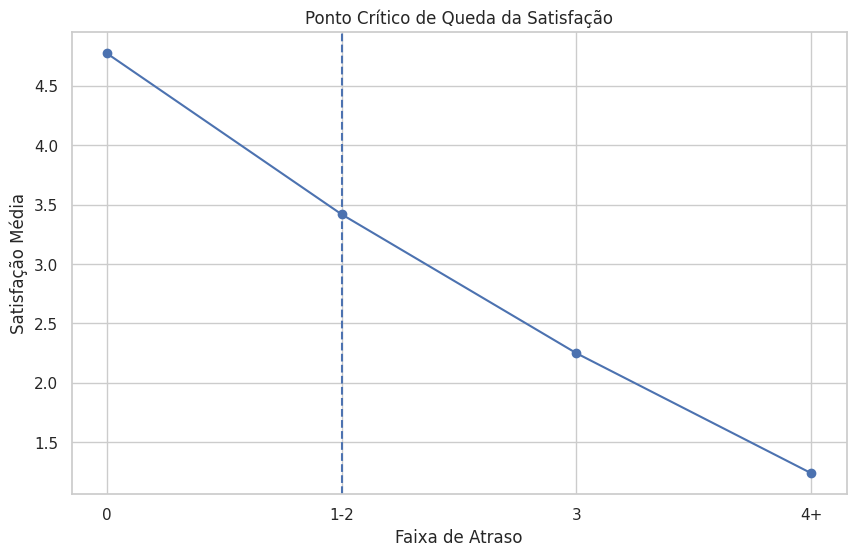

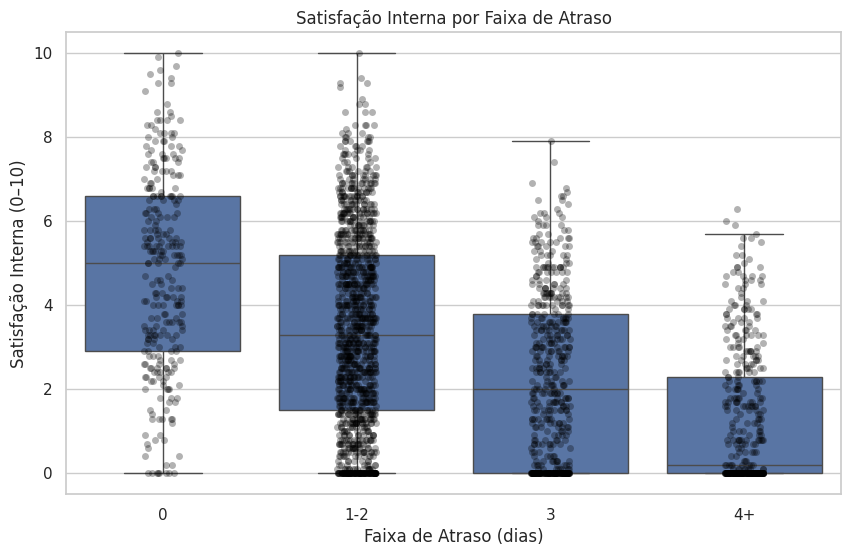

<Figure size 1000x600 with 0 Axes>

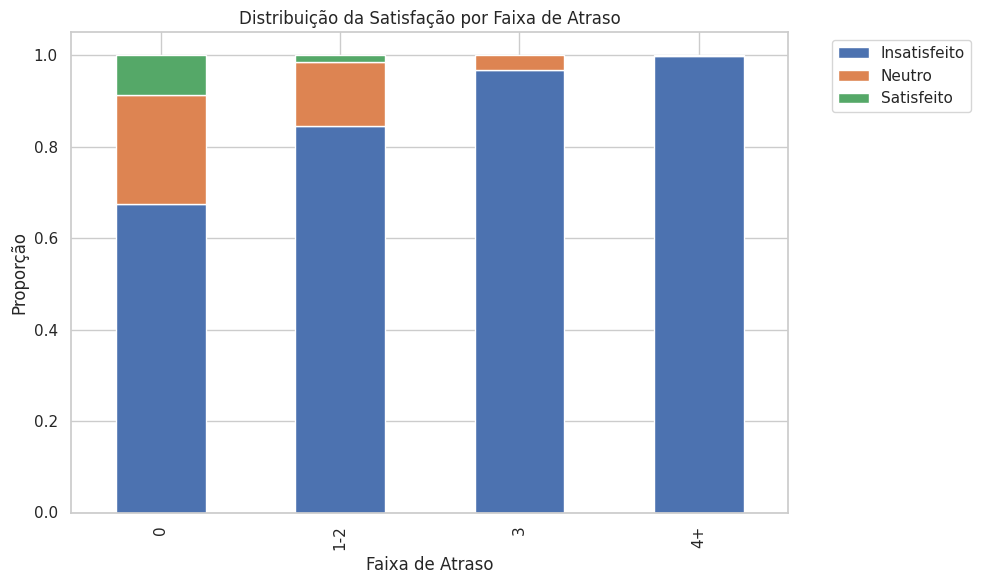

In [ ]:
# =========================
# 🎨 ESTILO
# =========================
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# =========================
# 📂 BASE
# =========================
df = df_desafio_nps_fase_1.copy()

# =========================
# 🧹 TRATAMENTO
# =========================
cols = [
    "atraso_entrega_dias",
    "pontuacao_satisfacao_interna"
]

df = df[cols].dropna()

# =========================
# 🆕 FAIXAS DE ATRASO (4+)
# =========================
df["faixa_atraso"] = pd.cut(
    df["atraso_entrega_dias"],
    bins=[-1, 0, 2, 3, float('inf')],
    labels=["0", "1-2", "3", "4+"]
)

ordem = ["0", "1-2", "3", "4+"]
df["faixa_atraso"] = pd.Categorical(df["faixa_atraso"], categories=ordem, ordered=True)

# =========================
# 📈 MÉDIA POR FAIXA (FALTAVA ISSO ❗)
# =========================
df_media = df.groupby("faixa_atraso")[
    "pontuacao_satisfacao_interna"
].mean().reset_index()

# =========================
# 🔥 DETECÇÃO DO PONTO CRÍTICO
# =========================
df_media["delta"] = df_media["pontuacao_satisfacao_interna"].diff()

queda_critica = df_media.loc[df_media["delta"].idxmin()]

ponto_critico = queda_critica["faixa_atraso"]
queda_valor = round(queda_critica["delta"], 2)

print("📉 INSIGHT:")
print(f"A maior queda ocorre na transição para a faixa {ponto_critico}")
print(f"Variação: {queda_valor}")

# =========================
# 📊 GRÁFICO COM PONTO CRÍTICO
# =========================
plt.figure()

plt.plot(
    df_media["faixa_atraso"],
    df_media["pontuacao_satisfacao_interna"],
    marker="o"
)

plt.axvline(
    x=list(df_media["faixa_atraso"]).index(ponto_critico),
    linestyle="--"
)

plt.title("Ponto Crítico de Queda da Satisfação")
plt.xlabel("Faixa de Atraso")
plt.ylabel("Satisfação Média")

plt.show()

# =========================
# 📦 BOXPLOT + STRIPPLOT
# =========================
plt.figure()

sns.boxplot(
    data=df,
    x="faixa_atraso",
    y="pontuacao_satisfacao_interna",
    showfliers=False
)

sns.stripplot(
    data=df,
    x="faixa_atraso",
    y="pontuacao_satisfacao_interna",
    color="black",
    alpha=0.3,
    jitter=True
)

plt.title("Satisfação Interna por Faixa de Atraso")
plt.xlabel("Faixa de Atraso (dias)")
plt.ylabel("Satisfação Interna (0–10)")

plt.show()

# =========================
# 🚀 CATEGORIZAÇÃO
# =========================
def classificar_satisfacao(score):
    if score <= 6:
        return "Insatisfeito"
    elif score <= 8:
        return "Neutro"
    else:
        return "Satisfeito"

df["categoria_satisfacao"] = df["pontuacao_satisfacao_interna"].apply(classificar_satisfacao)

# =========================
# 📊 PROPORÇÃO POR FAIXA
# =========================
prop = pd.crosstab(
    df["faixa_atraso"],
    df["categoria_satisfacao"],
    normalize="index"
)

plt.figure()

prop.plot(kind="bar", stacked=True)

plt.title("Distribuição da Satisfação por Faixa de Atraso")
plt.xlabel("Faixa de Atraso")
plt.ylabel("Proporção")

plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.show()

#**8.3** Com o objetivo de validar a premissa de que existe uma cadeia causal representada na sequencia de variáveis que envolvem a variável "intermediadora",

##foi feito o exercicio nas células a seguir  para explorar o impacto da variável "pontuacao_satisfacao_interna" sobre a variável "pontuacao_nps"

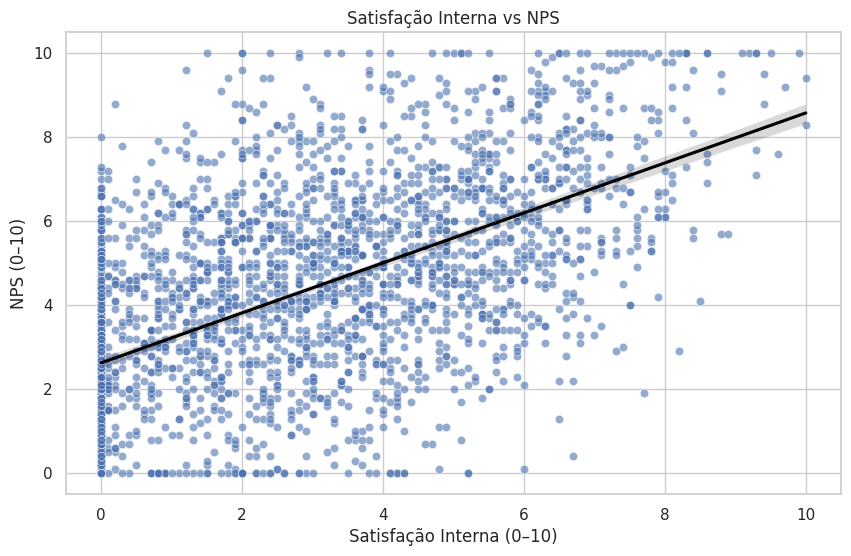

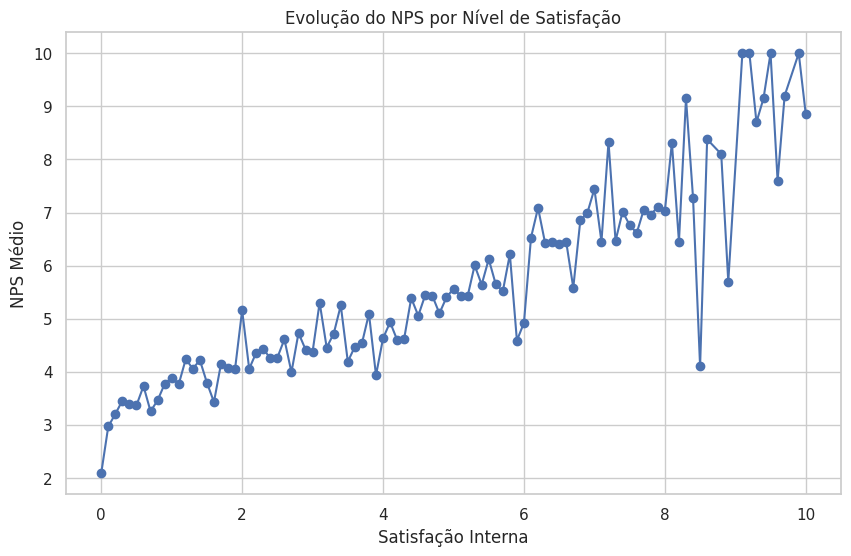

🚀 INSIGHT:
O maior aumento no NPS ocorre a partir de satisfação 9
Variação: +4.3


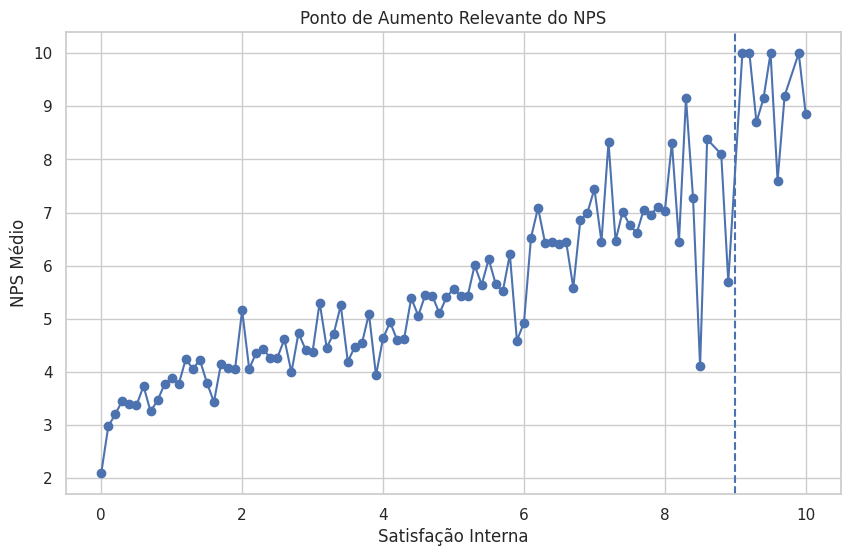

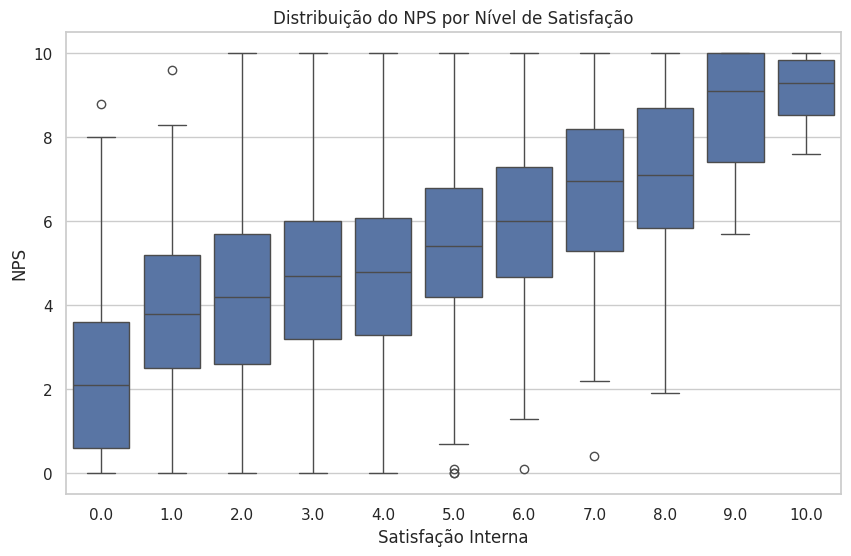

<Figure size 1000x600 with 0 Axes>

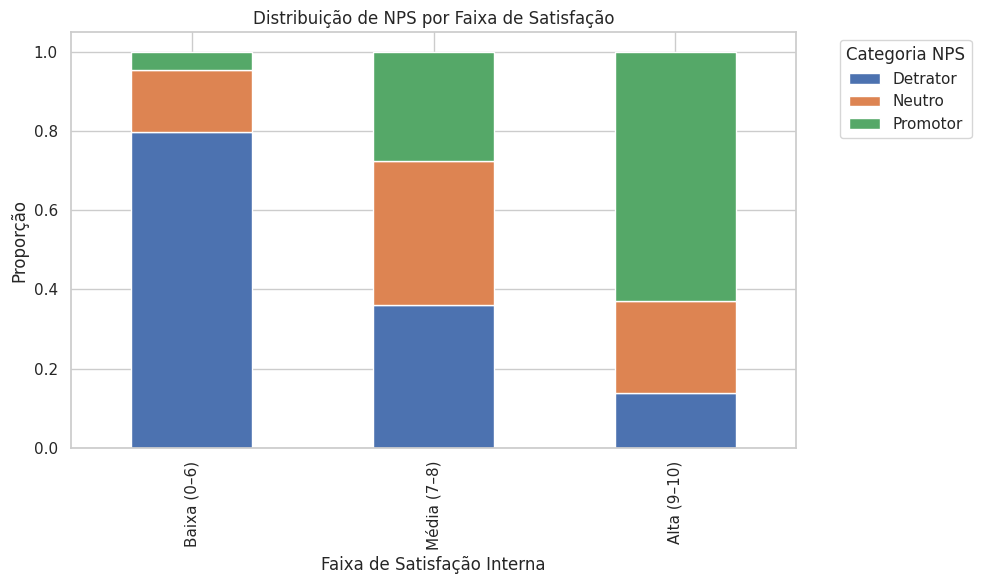

In [ ]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# =========================
# 📂 BASE
# =========================
df = df_desafio_nps_fase_1.copy()

# =========================
# 🧹 TRATAMENTO
# =========================
cols = [
    "pontuacao_satisfacao_interna",
    "pontuacao_nps"
]

df = df[cols].dropna()

# =========================
# 🎯 1. SCATTER + REGRESSÃO
# =========================
plt.figure()

sns.scatterplot(
    data=df,
    x="pontuacao_satisfacao_interna",
    y="pontuacao_nps",
    alpha=0.6
)

sns.regplot(
    data=df,
    x="pontuacao_satisfacao_interna",
    y="pontuacao_nps",
    scatter=False,
    color="black"
)

plt.title("Satisfação Interna vs NPS")
plt.xlabel("Satisfação Interna (0–10)")
plt.ylabel("NPS (0–10)")

plt.show()

# =========================
# 📈 2. MÉDIA POR SATISFAÇÃO
# =========================
df_media = df.groupby("pontuacao_satisfacao_interna")[
    "pontuacao_nps"
].mean().reset_index()

plt.figure()

plt.plot(
    df_media["pontuacao_satisfacao_interna"],
    df_media["pontuacao_nps"],
    marker="o"
)

plt.title("Evolução do NPS por Nível de Satisfação")
plt.xlabel("Satisfação Interna")
plt.ylabel("NPS Médio")

plt.show()

# =========================
# 🔥 3. DETECTAR PONTO DE SALTO
# =========================
df_media["delta"] = df_media["pontuacao_nps"].diff()

# maior crescimento (impacto positivo)
salto_critico = df_media.loc[df_media["delta"].idxmax()]

ponto_critico = int(salto_critico["pontuacao_satisfacao_interna"])
aumento = round(salto_critico["delta"], 2)

print("🚀 INSIGHT:")
print(f"O maior aumento no NPS ocorre a partir de satisfação {ponto_critico}")
print(f"Variação: +{aumento}")

# =========================
# 📊 4. GRÁFICO COM PONTO CRÍTICO
# =========================
plt.figure()

plt.plot(
    df_media["pontuacao_satisfacao_interna"],
    df_media["pontuacao_nps"],
    marker="o"
)

plt.axvline(ponto_critico, linestyle="--")

plt.title("Ponto de Aumento Relevante do NPS")
plt.xlabel("Satisfação Interna")
plt.ylabel("NPS Médio")

plt.show()

# =========================
# 📦 5. BOXPLOT
# =========================

# Criar variável arredondada
df["satisfacao_arred"] = df["pontuacao_satisfacao_interna"].round(0)

plt.figure()

sns.boxplot(
    data=df,
    x="satisfacao_arred",
    y="pontuacao_nps",
    order=sorted(df["satisfacao_arred"].unique())
)

plt.title("Distribuição do NPS por Nível de Satisfação")
plt.xlabel("Satisfação Interna")
plt.ylabel("NPS")

plt.show()

# =========================
# 🚀 6. CATEGORIZAÇÃO NPS
# =========================
def classificar_nps(score):
    if score <= 6:
        return "Detrator"
    elif score <= 8:
        return "Neutro"
    else:
        return "Promotor"

df["categoria_nps"] = df["pontuacao_nps"].apply(classificar_nps)

# =========================
# 📊 7. PROPORÇÃO (GRÁFICO EXECUTIVO - COM FAIXAS)
# =========================

# Criar faixas de satisfação
bins = [0, 6, 8, 10]
labels = ["Baixa (0–6)", "Média (7–8)", "Alta (9–10)"]

df["faixa_satisfacao"] = pd.cut(
    df["pontuacao_satisfacao_interna"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Crosstab com proporção
prop = pd.crosstab(
    df["faixa_satisfacao"],
    df["categoria_nps"],
    normalize="index"
)

plt.figure()

prop.plot(kind="bar", stacked=True)

plt.title("Distribuição de NPS por Faixa de Satisfação")
plt.xlabel("Faixa de Satisfação Interna")
plt.ylabel("Proporção")

plt.legend(
    title="Categoria NPS",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

## 🔍Na medida que a pontuação satisfação interna aumenta a pontuacao NPS aumenta no pós-venda

## 📊 Análise de impacto do tempo de resolução no NPS

Coniserando a premissa de causalidade na correlação:

##“Se eu reduzir 1(um) dia no tempo de resolução, quanto o NPS aumenta — considerando o efeito via satisfação?”

In [ ]:
# =========================================
# 1. CÓPIA DO DATAFRAME
# =========================================
df = df_desafio_nps_fase_1.copy()

# =========================================
# 2. MODELO 1 → tempo → satisfação
# =========================================
X1 = sm.add_constant(df["tempo_resolucao_dias"])
y1 = df["pontuacao_satisfacao_interna"]

model_satisfacao = sm.OLS(y1, X1).fit()

beta_tempo_satisfacao = model_satisfacao.params["tempo_resolucao_dias"]

print("\n📊 Modelo 1: Tempo → Satisfação")
print(model_satisfacao.summary())

# =========================================
# 3. MODELO 2 → satisfação → NPS
# =========================================
X2 = sm.add_constant(df["pontuacao_satisfacao_interna"])
y2 = df["pontuacao_nps"]

model_nps = sm.OLS(y2, X2).fit()

beta_satisfacao_nps = model_nps.params["pontuacao_satisfacao_interna"]

print("\n📊 Modelo 2: Satisfação → NPS")
print(model_nps.summary())

# =========================================
# 4. EFEITO INDIRETO (MEDIAÇÃO)
# =========================================
efeito_indireto = beta_tempo_satisfacao * beta_satisfacao_nps

print("\n🎯 EFEITO INDIRETO (via satisfação)")
print(f"Impacto no NPS para +1 dia: {efeito_indireto:.4f}")
print(f"Impacto no NPS para -1 dia: {-efeito_indireto:.4f}")

# =========================================
# 5. MODELO COMPLETO (direto + indireto)
# =========================================
X3 = sm.add_constant(df[
    ["tempo_resolucao_dias", "pontuacao_satisfacao_interna"]
])
y3 = df["pontuacao_nps"]

model_total = sm.OLS(y3, X3).fit()

print("\n📊 Modelo completo (efeito direto + mediado)")
print(model_total.summary())

# =========================================
# 6. SIMULAÇÃO: impacto por cliente
# =========================================
df["delta_satisfacao_-1dia"] = beta_tempo_satisfacao * (-1)
df["delta_nps_-1dia"] = df["delta_satisfacao_-1dia"] * beta_satisfacao_nps

impacto_medio = df["delta_nps_-1dia"].mean()

print("\n📈 SIMULAÇÃO")
print(f"Impacto médio no NPS ao reduzir 1 dia: {impacto_medio:.4f}")

# =========================================
# 7. INTERPRETAÇÃO AUTOMÁTICA
# =========================================
print("\n🧠 INTERPRETAÇÃO:")
print(
    f"Reduzir 1 dia no tempo de resolução aumenta o NPS em aproximadamente "
    f"{abs(impacto_medio):.2f} pontos, via melhora na satisfação interna."
)


📊 Modelo 1: Tempo → Satisfação
                                 OLS Regression Results                                 
Dep. Variable:     pontuacao_satisfacao_interna   R-squared:                       0.545
Model:                                      OLS   Adj. R-squared:                  0.545
Method:                           Least Squares   F-statistic:                     2996.
Date:                          Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                                  19:08:13   Log-Likelihood:                -4728.3
No. Observations:                          2500   AIC:                             9461.
Df Residuals:                              2498   BIC:                             9472.
Df Model:                                     1                                         
Covariance Type:                      nonrobust                                         
                           coef    std err          t      P>|t|      [0.025  

## 📊 Análise de impacto do atraso de entrega na satisfação do cliente

Coniserando a premissa de causalidade na correlação:




📊 Modelo: Atraso → Satisfação
                                 OLS Regression Results                                 
Dep. Variable:     pontuacao_satisfacao_interna   R-squared:                       0.211
Model:                                      OLS   Adj. R-squared:                  0.210
Method:                           Least Squares   F-statistic:                     666.9
Date:                          Mon, 06 Apr 2026   Prob (F-statistic):          1.50e-130
Time:                                  19:08:13   Log-Likelihood:                -5417.7
No. Observations:                          2500   AIC:                         1.084e+04
Df Residuals:                              2498   BIC:                         1.085e+04
Df Model:                                     1                                         
Covariance Type:                      nonrobust                                         
                          coef    std err          t      P>|t|      [0.025    

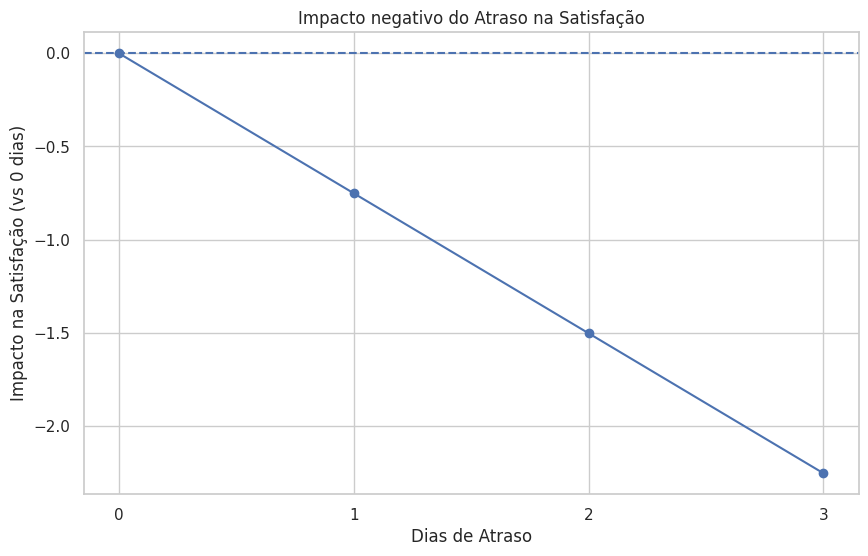


🧠 INSIGHT FINAL:
Cada dia adicional de atraso reduz a satisfação em aproximadamente 0.75 pontos.
Um atraso de 3 dias pode reduzir a satisfação em aproximadamente 2.25 pontos.
Garantir entregas no prazo (0 dias de atraso) é essencial para manter altos e/ou estáveis os níveis de satisfação do cliente.


In [ ]:
# =========================================
# 📂 BASE
# =========================================
df = df_desafio_nps_fase_1.copy()

df = df[
    ["atraso_entrega_dias", "pontuacao_satisfacao_interna"]
].dropna()

# =========================================
# 📊 MODELO → atraso → satisfação
# =========================================
X = sm.add_constant(df["atraso_entrega_dias"])
y = df["pontuacao_satisfacao_interna"]

model = sm.OLS(y, X).fit()

beta_atraso = model.params["atraso_entrega_dias"]

print("\n📊 Modelo: Atraso → Satisfação")
print(model.summary())

# =========================================
# 🎯 INTERPRETAÇÃO DIRETA
# =========================================
print("\n🎯 INTERPRETAÇÃO DIRETA")
print(f"Impacto na satisfação para +1 dia de atraso: {beta_atraso:.4f}")
print(f"Impacto na satisfação para -1 dia de atraso: {-beta_atraso:.4f}")

# =========================================
# 🚀 SIMULAÇÃO DE CENÁRIOS
# =========================================
cenarios = [0, 1, 2, 3]

df_simulacao = pd.DataFrame({
    "dias_atraso": cenarios
})

# impacto relativo ao cenário ideal (0 dias)
df_simulacao["impacto_satisfacao_vs_0"] = df_simulacao["dias_atraso"] * beta_atraso

print("\n📊 SIMULAÇÃO DE CENÁRIOS (vs 0 dias)")
print(df_simulacao)

# =========================================
# 📈 GRÁFICO
# =========================================
plt.figure()

plt.plot(
    df_simulacao["dias_atraso"],
    df_simulacao["impacto_satisfacao_vs_0"],
    marker="o"
)

plt.axhline(0, linestyle="--")

# 👇 FORÇAR EIXO X COM INTEIROS
plt.xticks(df_simulacao["dias_atraso"])

plt.title("Impacto negativo do Atraso na Satisfação")
plt.xlabel("Dias de Atraso")
plt.ylabel("Impacto na Satisfação (vs 0 dias)")

plt.show()

# =========================================
# 🧠 INTERPRETAÇÃO FINAL
# =========================================
print("\n🧠 INSIGHT FINAL:")

print(
    f"Cada dia adicional de atraso reduz a satisfação em aproximadamente "
    f"{abs(beta_atraso):.2f} pontos."
)

print(
    f"Um atraso de 3 dias pode reduzir a satisfação em aproximadamente "
    f"{abs(3 * beta_atraso):.2f} pontos."
)

print(
    "Garantir entregas no prazo (0 dias de atraso) é essencial para manter "
    "altos e/ou estáveis os níveis de satisfação do cliente."
)

## 🔍A entrega no prazo (o(zero) dias de atraso) não aumenta a satisfação do cliente, mas para cada dia de atraso o nível de satisfação vai sendo impactado negativamente.

#📊**9**.MODELOs PREDITIVO NPS

#**9.1** Tratando dataset para o modelo preditivo removendo colunas para evitar leackage (pontuacao_nps, categoria_nps, recompra_30_dias) e/ou colunas criadas no dataframe de trabalho e que estão com informações redundantes/nao relevantes para o modelo ( coluna id_cliente, id pedido  e colunas de faixas etarias, faixa tempo de relacionamento, faixa valor do pedido e faixa atraso entrega )  

##Observação: A premissa usada foi que a coluna recompra_30_dias é uma informação que não existia no momento que o cliente respondeu a pesquisa que gerou sua pontuacao NPS


In [ ]:
df_desafio_nps_fase_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 28 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   id_cliente                          2500 non-null   int64   
 1   idade_cliente                       2500 non-null   int64   
 2   tempo_relacionamento_cliente_meses  2500 non-null   int64   
 3   id_pedido                           2500 non-null   int64   
 4   valor_pedido                        2500 non-null   float64 
 5   quantidade_itens                    2500 non-null   int64   
 6   valor_desconto                      2500 non-null   float64 
 7   numero_parcelas_pagamento           2500 non-null   int64   
 8   tempo_entrega_dias                  2500 non-null   int64   
 9   atraso_entrega_dias                 2500 non-null   int64   
 10  valor_frete                         2500 non-null   float64 
 11  tentativas_entrega            

In [ ]:
cols_remover = [
"id_cliente", "id_pedido", "recompra_30_dias", "faixa_etaria", "faixa_relacionamento", "faixa_valor_pedido", "faixa_atraso",
]

df_modelo = df_desafio_nps_fase_1.drop(columns=cols_remover)

#**9.2** Montando dataframes x e y para o modelo preditivo NPS, sendo x as variaveis tradicionalmente chamadas "features" e em y somente a variavel tradicionalmente chamada "target" que é a variavel que o modelo deve ser treinado para prever

In [ ]:
X = df_modelo.drop(columns=["pontuacao_nps", "categoria_nps"])
X = X.replace({True: 1, False: 0})
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   idade_cliente                       2500 non-null   int64  
 1   tempo_relacionamento_cliente_meses  2500 non-null   int64  
 2   valor_pedido                        2500 non-null   float64
 3   quantidade_itens                    2500 non-null   int64  
 4   valor_desconto                      2500 non-null   float64
 5   numero_parcelas_pagamento           2500 non-null   int64  
 6   tempo_entrega_dias                  2500 non-null   int64  
 7   atraso_entrega_dias                 2500 non-null   int64  
 8   valor_frete                         2500 non-null   float64
 9   tentativas_entrega                  2500 non-null   int64  
 10  contatos_atendimento_cliente        2500 non-null   int64  
 11  tempo_resolucao_dias                2500 no

In [ ]:
y = df_modelo["pontuacao_nps"]
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 2500 entries, 0 to 2499
Series name: pontuacao_nps
Non-Null Count  Dtype  
--------------  -----  
2500 non-null   float64
dtypes: float64(1)
memory usage: 19.7 KB


#**9.3** Realizando o SPLIT de TREINO ( x e y ) e TESTE ( x e y )

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#**9.4** Treinando o modelo de REGRESSAO LINEAR (TARGET NUMERICO CONTINUO)  

##pontuacao_nps

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =========================================
# 2. DEFINIR X e y
# =========================================
X = df_modelo.drop(columns=["pontuacao_nps", "categoria_nps"])
y = df_modelo["pontuacao_nps"]

# =========================================
# 3. AJUSTES (IMPORTANTE)
# =========================================
# converter boolean para 0/1
X = X.replace({True: 1, False: 0})

# =========================================
# 4. SPLIT TREINO / TESTE
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================
# 5. PIPELINE
# =========================================
model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# =========================================
# 6. TREINAR MODELO
# =========================================
model.fit(X_train, y_train)

# =========================================
# 7. FAZER PREDIÇÕES
# =========================================
y_pred = model.predict(X_test)

# =========================================
# 8. MÉTRICAS DE AVALIAÇÃO
# =========================================
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("===== MÉTRICAS =====")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

# =========================================
# 9. COMPARAR REAL vs PREVISTO
# =========================================
comparacao = pd.DataFrame({
    "real": y_test.values,
    "previsto": y_pred
})

print("\n===== AMOSTRA DE PREVISÕES =====")
print(comparacao.head(10))

# =========================================
# 10. IMPACTO DAS VARIÁVEIS (COEFICIENTES)
# =========================================
coef = model.named_steps['regressor'].coef_

impacto = pd.DataFrame({
    'feature': X_train.columns,
    'impacto': coef
}).sort_values(by='impacto', ascending=False)

print("\n===== IMPACTO DAS VARIÁVEIS =====")
print(impacto)

# =========================================
# 11. (OPCIONAL) RANKING POR IMPACTO ABSOLUTO
# =========================================
impacto['abs'] = impacto['impacto'].abs().round(2)

impacto_abs = impacto.sort_values(by='abs', ascending=False)

print("\n===== TOP DRIVERS (ABSOLUTO) =====")
print(impacto_abs.head(10))

===== MÉTRICAS =====
RMSE: 1.6883531667954204
MAE: 1.332333149555698
R2: 0.5488737586435073

===== AMOSTRA DE PREVISÕES =====
   real  previsto
0   6.8  5.422004
1   6.0  6.320032
2   8.3  8.083455
3   5.3  4.497156
4   6.8  7.080814
5   0.0  1.674196
6   1.4 -0.347536
7   7.4  5.895780
8   5.2  4.523056
9   0.8  3.406557

===== IMPACTO DAS VARIÁVEIS =====
                               feature   impacto
13        pontuacao_satisfacao_interna  0.130931
2                         valor_pedido  0.117256
9                   tentativas_entrega  0.094257
18                          regiao_Sul  0.039601
5            numero_parcelas_pagamento  0.036036
6                   tempo_entrega_dias  0.030220
3                     quantidade_itens  0.019062
16                        regiao_Norte  0.014705
0                        idade_cliente  0.007626
17                      regiao_Sudeste -0.000093
15                     regiao_Nordeste -0.003597
4                       valor_desconto -0.045234
14  

##📊 🔥 VISÃO GERAL DO MODELO e possíveis inferências

##“Reduzir atrasos em 1 dia pode gerar ganho de até 1.3 pontos no NPS, sendo o principal driver da satisfação do cliente.”  

🎯 “O que mais destrói o NPS?”  

*   Atraso na entrega
*   Reclamações
*   Tempo de resolução

🎯 “Onde focar primeiro?”

*   👉 Logística e atendimento

📌 Observação para os casos de muitos contatos e reclamações:

*   👉 não são causa — são efeito de problema anterior
*   💥 raiz do problema = entrega + experiência  


📊 🎯 QUALIDADE DO MODELO  

🔹 Métricas  

RMSE: 1.69  

MAE: 1.33  

R²: 0.55  

🧠 Interpretação  

👉 MODELO:  

explica ~55% do comportamento do NPS  
erra em média ~1.3 pontos  

💥 Conclusão: modelo bom e utilizável  

⚠️ Observação importante:

Temos casos como:  

real: 0.8 → previsto: 3.4  
real: 1.4 → previsto: -0.34  

👉 Isso mostra:  

erro maior em extremos  
modelo linear tem dificuldade com não-linearidade  

🔥 📉 PRINCIPAIS DRIVERS (O OURO)  

🟥 TOP FATORES NEGATIVOS  

🥇 atraso_entrega_dias (-1.30)  

Cada +1 dia de atraso → -1.3 pontos no NPS  

💥 principal driver disparado  

🥈 quantidade_reclamacoes (-0.67)  

Cada reclamação → -0.67 pontos  

🥉 tempo_resolucao_dias (-0.42)  

Cada dia a mais → -0.42 pontos  

🔴 Outros relevantes  

contatos atendimento → -0.37  

valor frete → -0.10

📈 🟢 DRIVERS POSITIVOS  

🥇 satisfação interna (+0.13)  

👉 coerente (proxy de experiência)  

🥈 valor pedido (+0.12)  

👉 cliente mais engajado = mais satisfeito  

🥉 tentativas entrega (+0.09)  

👉 persistência melhora experiência  

🧠 INSIGHT MAIS IMPORTANTE  

💥 “Logística domina o NPS”  

Especialmente:  

atraso  
reclamação  
resolução  

👉 tudo converge para experiência operacional  

🚀 📊 SIMULAÇÃO

Exemplo real:  

Se você reduzir:  

1 dia de atraso  
1 reclamação  

👉 impacto esperado:  

+1.30 + 0.67 = +1.97 pontos no NPS  

💥 isso é ENORME  

⚠️ INSIGHT AVANÇADO  

🔴 **Contatos e reclamações são sintomas**  

👉 **não são causa raiz**   

👉 raiz está em:  

entrega  
experiência ruim  

📊

“Os principais drivers de insatisfação estão relacionados à experiência logística e de atendimento, com destaque para atraso na entrega, volume de reclamações e tempo de resolução, que apresentam os maiores impactos negativos no NPS.”  

🎯 PRIORIDADE DE AÇÃO  

🔥 Top 3  
reduzir atraso  
reduzir reclamações  
acelerar resolução  

#**9.5** Treinando o modelo de REGRESSAO LOGISTICA ( TARGET NPS CATEGORICO )

## *   Detrator
## *   Neutro
## *   Promotor

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# =========================================
# 2. DEFINIR X e y
# =========================================
X = df_modelo.drop(columns=["categoria_nps", "pontuacao_nps"])
y = df_modelo["categoria_nps"]

# =========================================
# 3. AJUSTES DE DADOS
# =========================================

# converter boolean para int
X = X.replace({True: 1, False: 0})

# codificar target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# =========================================
# 4. SPLIT TREINO / TESTE
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# =========================================
# 5. PIPELINE (COM BALANCEAMENTO)
# =========================================
model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000,
        multi_class='ovr',
        class_weight='balanced'  # 🔥 AQUI ESTÁ A MUDANÇA
    ))
])

# =========================================
# 6. TREINO
# =========================================
model.fit(X_train, y_train)

# =========================================
# 7. PREDIÇÕES
# =========================================
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# =========================================
# 8. MÉTRICAS
# =========================================

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("\n=== Matriz de Confusão ===")
print(confusion_matrix(y_test, y_pred))

# ROC AUC multiclass
auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print("\nROC AUC (multiclass):", auc)

# =========================================
# 9. IMPORTÂNCIA DAS VARIÁVEIS
# =========================================

coef = model.named_steps['clf'].coef_

for i, classe in enumerate(le.classes_):
    print(f"\n=== Impacto para classe: {classe} ===")

    impacto = pd.DataFrame({
        'feature': X_train.columns,
        'coef': coef[i]
    }).sort_values(by='coef', ascending=False)

    print(impacto.head(10))

=== Classification Report ===
              precision    recall  f1-score   support

    Detrator       0.91      0.80      0.85       363
      Neutro       0.41      0.45      0.43        98
    Promotor       0.26      0.49      0.34        39

    accuracy                           0.71       500
   macro avg       0.53      0.58      0.54       500
weighted avg       0.76      0.71      0.73       500


=== Matriz de Confusão ===
[[291  47  25]
 [ 26  44  28]
 [  4  16  19]]

ROC AUC (multiclass): 0.8445121147851262

=== Impacto para classe: Detrator ===
                               feature      coef
12              quantidade_reclamacoes  1.522274
7                  atraso_entrega_dias  1.353283
11                tempo_resolucao_dias  0.625217
8                          valor_frete  0.172750
1   tempo_relacionamento_cliente_meses  0.085126
13        pontuacao_satisfacao_interna  0.083750
4                       valor_desconto  0.079593
16                        regiao_Norte  0.

#🔍 Situação Atual da distribuição por categoria de NPS

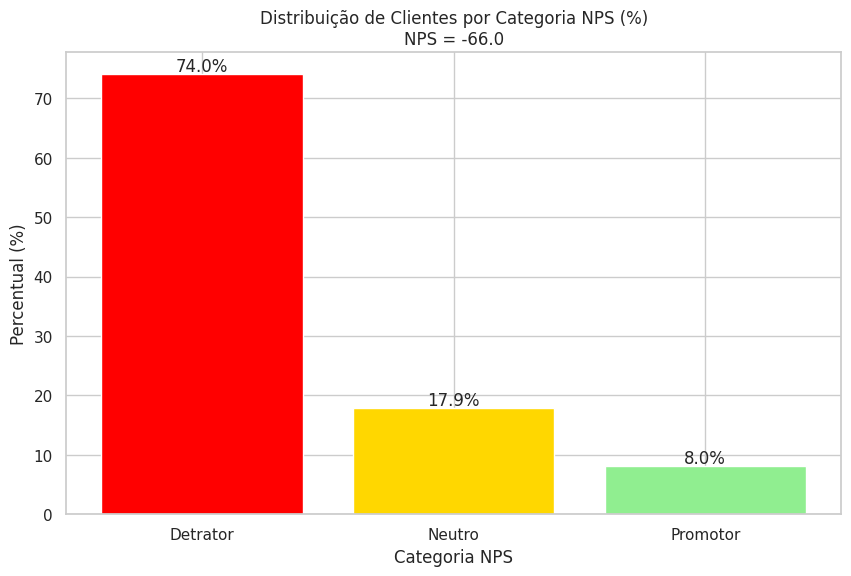

In [ ]:
ordem = ['Detrator', 'Neutro', 'Promotor']

percentuais = (
    df_modelo['categoria_nps']
    .value_counts(normalize=True)
    .reindex(ordem)
    .fillna(0)
    .mul(100)
)

# cálculo do NPS
nps = percentuais['Promotor'] - percentuais['Detrator']

# cores personalizadas
cores = ['red', 'gold', 'lightgreen']

plt.figure()

bars = plt.bar(percentuais.index, percentuais.values, color=cores)

plt.title(f'Distribuição de Clientes por Categoria NPS (%)\nNPS = {nps:.1f}')
plt.xlabel('Categoria NPS')
plt.ylabel('Percentual (%)')

# rótulos nas barras
for i, v in enumerate(percentuais):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.show()

##📊 🔥 VISÃO GERAL DO MODELO e possíveis inferências

🎯 Métricas principais  

Accuracy: 0.71  

ROC AUC: 0.84 💥  

Macro F1: 0.54  

🧠 Interpretação direta  

👉 Modelo bom e utilizável  

AUC 0.84 → excelente capacidade de separação  
Accuracy 0.71 → consistente  
Macro avg mais baixo → esperado (classes desbalanceadas)  

📊 🔍 MATRIZ DE CONFUSÃO

[[291  47  25]   → Detrator  
 [ 26  44  28]   → Neutro  
 [  4  16  19]]  → Promotor

🟥 Detrator  

👉 291 acertos de 363

recall ≈ 80%  
poucos falsos negativos  

🟡 Neutro  

👉 44 acertos de 98  

modelo ainda confunde bastante  
principalmente com promotor  

⚠️ comportamento esperado

🟢 Promotor  

👉 19 acertos de 39 (~49%)  

💥 grande evolução  

🔥 INSIGHT PRINCIPAL

O modelo consegue diferenciar bem clientes insatisfeitos e apresenta boa capacidade geral de separação entre os níveis de satisfação (AUC 0.84), com maior dificuldade na identificação de perfis intermediários (neutros).

🧠 📈 INTERPRETAÇÃO DOS DRIVERS  

🚨 🟥 DETRATOR — O QUE GERA INSATISFAÇÃO  

Top fatores:  

quantidade_reclamacoes (+1.52)  

atraso_entrega_dias (+1.35)  

tempo_resolucao_dias (+0.62)  

💥 Tradução direta  

Reclamações + atraso + demora = cliente insatisfeito  

👉 isso é MUITO claro no modelo  

📊 🟡 NEUTRO — PERFIL INTERMEDIÁRIO  

mais contatos com atendimento  
ticket médio moderado  
entrega razoável  

👉 cliente “ok, mas não encantado”  

🌟 🟢 PROMOTOR — O QUE GERA SATISFAÇÃO  

Top fatores:  

tentativas_entrega (+0.20)

idade_cliente (+0.16)  

valor_pedido (+0.11)  

💡 Insight interessante  

👉 insistência na entrega ajuda  

👉 clientes mais engajados (ticket maior) → mais satisfeitos  

⚠️ INSIGHT AVANÇADO

🔴 Fatores negativos ≠ positivos invertidos  

👉 **O que causa insatisfação NÃO é simplesmente o oposto do que gera satisfação**  

Exemplo:    

**atraso gera detrator** ❌  

**mas não necessariamente eliminar atraso cria promotor**

🎯 PRIORIDADES DE NEGÓCIO

🔥 1. Reduzir atraso de entrega  

🔥 2. Reduzir reclamações  

🔥 3. Melhorar tempo de resolução

| AUC       | Interpretação              |
| --------- | -------------------------- |
| 0.5       | modelo aleatório (ruim)    |
| 0.6 – 0.7 | fraco                      |
| 0.7 – 0.8 | ok                         |
| 0.8 – 0.9 | bom                        |
| > 0.9     | excelente (ou suspeito 👀) |


| Gap          | Diagnóstico  |
| ------------ | ------------ |
| < 0.02       | ótimo        |
| 0.02 – 0.05  | aceitável    |
| > 0.05       | overfitting  |
| ambos baixos | underfitting |


#**9.6** Treinando o modelo de REGRESSAO LOGISTICA BINÁRIA ( TARGET NPS CATEGORICO )

## *   Detrator
## *   Não Detrator


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.58      0.82      0.68       130
           1       0.92      0.79      0.85       370

    accuracy                           0.80       500
   macro avg       0.75      0.80      0.76       500
weighted avg       0.83      0.80      0.81       500


=== Matriz de Confusão ===
[[106  24]
 [ 78 292]]

ROC AUC: 0.8767359667359668


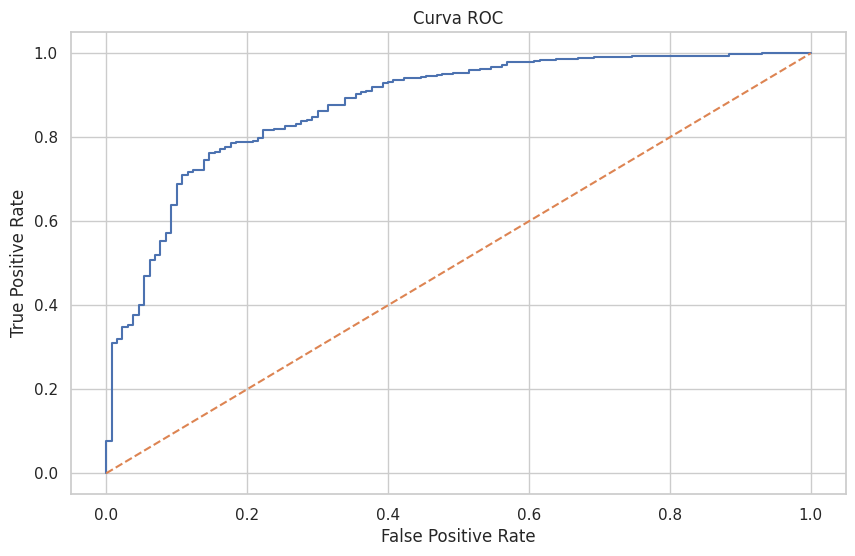


=== Impacto das variáveis ===
                               feature   impacto
12              quantidade_reclamacoes  1.461788
7                  atraso_entrega_dias  1.452968
11                tempo_resolucao_dias  0.646123
8                          valor_frete  0.095692
13        pontuacao_satisfacao_interna  0.093449
1   tempo_relacionamento_cliente_meses  0.065791
4                       valor_desconto  0.043868
14                 regiao_Centro-Oeste  0.034880
6                   tempo_entrega_dias  0.030557
16                        regiao_Norte  0.026431
0                        idade_cliente  0.006848
15                     regiao_Nordeste -0.003290
3                     quantidade_itens -0.012623
18                          regiao_Sul -0.013231
10        contatos_atendimento_cliente -0.015215
5            numero_parcelas_pagamento -0.034490
17                      regiao_Sudeste -0.043046
9                   tentativas_entrega -0.061446
2                         valor_pedido

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt

# ==========================================================================================
# 2. CRIAR TARGET BINÁRIO - Definindo "Detrator" como sendo 1 e "Não detrator" como sendo 0
# ==========================================================================================
df_modelo["nps_binario"] = df_modelo["categoria_nps"].apply(
    lambda x: 1 if x == "Detrator" else 0
)

# =========================================
# 3. DEFINIR X e y
# =========================================
X = df_modelo.drop(columns=["categoria_nps", "pontuacao_nps", "nps_binario"])
y = df_modelo["nps_binario"]

# =========================================
# 4. AJUSTES
# =========================================
X = X.replace({True: 1, False: 0})

# =========================================
# 5. SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================
# 6. PIPELINE
# =========================================
model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'  # 🔥 importante
    ))
])

# =========================================
# 7. TREINO
# =========================================
model.fit(X_train, y_train)

# =========================================
# 8. PREDIÇÕES
# =========================================
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# =========================================
# 9. MÉTRICAS
# =========================================
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("\n=== Matriz de Confusão ===")
print(confusion_matrix(y_test, y_pred))

auc = roc_auc_score(y_test, y_pred_proba)
print("\nROC AUC:", auc)

# =========================================
# 10. CURVA ROC
# =========================================
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.show()

# =========================================
# 11. IMPORTÂNCIA DAS VARIÁVEIS
# =========================================
coef = model.named_steps['clf'].coef_[0]

impacto = pd.DataFrame({
    'feature': X_train.columns,
    'impacto': coef
}).sort_values(by='impacto', ascending=False)

print("\n=== Impacto das variáveis ===")
print(impacto)

##📊 🔥 VISÃO GERAL DO MODELO e possíveis inferências

🔥 Métricas principais  

AUC: 0.877 💥
Accuracy: 0.80  
Recall (detrator): 0.79  
Precision (detrator): 0.92  

🧠 Interpretação direta  

👉 modelo:

✔ separa muito bem clientes (AUC alto)  
✔ identifica bem detratores  
✔ erra pouco quando prevê detrator  

💥 Conclusão: modelo excelente para uso real  

🚨 📊 MATRIZ DE CONFUSÃO

[[106  24]   → não detrator  
 [ 78 292]]  → detrator  

INTERPRETANDO AS POSIÇÕES NA MATRIZ DE CONFUSÃO  

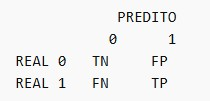

🟥 Detratores (classe 1)  

292 acertos  

78 perdidos  

👉 recall = 79%  

💥 Captura a maioria dos problemas  

🟩 Não detratores (classe 0)  

106 acertos  
24 falsos positivos  

👉 precision alto → modelo confiável  

🔥 O MAIS IMPORTANTE  

🎯 Modelo responde:  

“qual a chance desse cliente ser detrator?”  

👉 isso é ação direta  

📈 🔥 INTERPRETAÇÃO DOS DRIVERS  

🚨 TOP FATORES QUE GERAM DETRATOR  

🥇 quantidade_reclamacoes (+1.46)  

👉 quanto mais reclama → muito mais chance de detrator  

🥈 atraso_entrega_dias (+1.45)  

👉 impacto praticamente igual ao anterior  

💥 fortíssimo  

🥉 tempo_resolucao_dias (+0.64)  

🔴 Outros relevantes  

valor_frete  
satisfação interna  

🧠 Insight MUITO importante  

👉 O modelo confirma exatamente o que a regressão mostrou  

💥 consistência entre modelos = altíssima confiança  

⚠️ Insight avançado  

📌 valor_pedido (-0.17)  

👉 clientes que compram mais → MENOS chance de ser detrator  

📌 tentativas_entrega (-0.06)  

👉 insistir na entrega reduz risco  

🔥 FOCO TOTAL:  

reduzir reclamações  
reduzir atraso  
acelerar resolução  